# Séminaire — Présentation des résultats (Sprints 32-35 + 39)

**Projet CL-Embedded** — Apprentissage incrémental sur microcontrôleur NUCLEO-F439ZI (Cortex-M4, 256 Ko SRAM).

Ce notebook **rassemble et exporte en PNG** tous les plots importants de cinq études :

| Sprint | Sujet |
|--------|-------|
| 32 | Impact du seuil de labélisation RUL → `faulty` |
| 33 | Profilage énergétique & métriques de coût (FLOPs / BOPs / latence / autonomie) |
| 34 | Streaming/buffer & Q15 pour Mahalanobis |
| 35 | Impact du nombre de features (5feat / all / best) |
| 39 | INT8 vs FP32 — ablation de la perte F1 + campagne trade-off |

Les figures sont écrites dans `docs/PresentationJuillet/figures/` et référencées par `seminaire.md`.
Aucune valeur n'est saisie à la main : tout provient de `experiments/`.


In [1]:
import json, sys, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

# ROOT robuste : remonte jusqu'à trouver experiments/
ROOT = Path.cwd()
for _ in range(6):
    if (ROOT / "experiments").exists():
        break
    ROOT = ROOT.parent
assert (ROOT / "experiments").exists(), f"experiments/ introuvable depuis {Path.cwd()}"
sys.path.insert(0, str(ROOT))
EXP = ROOT / "experiments"

FIG = ROOT / "docs" / "PresentationJuillet" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

MCOLOR = {"ewc": "#1f77b4", "hdc": "#ff7f0e", "tinyol": "#2ca02c", "mahalanobis": "#9467bd"}

def save(name):
    """Sauvegarde la figure courante en PNG (dpi=150) dans figures/."""
    plt.savefig(FIG / name, dpi=150, bbox_inches="tight")
    print("saved", name)

print("ROOT =", ROOT)
print("FIG  =", FIG)

ROOT = /home/leonard/Documents/ENAC/cl-embedded
FIG  = /home/leonard/Documents/ENAC/cl-embedded/docs/PresentationJuillet/figures


---
# Sprint 32 — Impact du seuil de labélisation RUL → `faulty`

Le seuil qui convertit la RUL (Remaining Useful Life) en label binaire `faulty` est un
hyperparamètre (`TODO(arnaud)`). On balaie 5 seuils × 4 modèles × 3 datasets sur **PC (60 runs)**
et **board (60 runs)**.

In [2]:
pc32 = pd.DataFrame(json.loads((EXP / "exp_S32_sweep_summary.json").read_text()))
bd32 = pd.DataFrame(json.loads((EXP / "exp_S32_board_sweep_summary.json").read_text()))
MODELS32 = ["ewc", "hdc", "tinyol", "mahalanobis"]
DATASETS32 = ["cmapss", "pronostia", "battery"]
print("PC   :", len(pc32), "runs |", sorted(pc32.model.unique()), "×", sorted(pc32.dataset.unique()))
print("Board:", len(bd32), "runs | parity_class:", sorted(bd32.parity_class.unique()))

PC   : 60 runs | ['ewc', 'hdc', 'mahalanobis', 'tinyol'] × ['battery', 'cmapss', 'pronostia']
Board: 60 runs | parity_class: ['hw_only', 'parity']


saved s32_positive_ratio.png


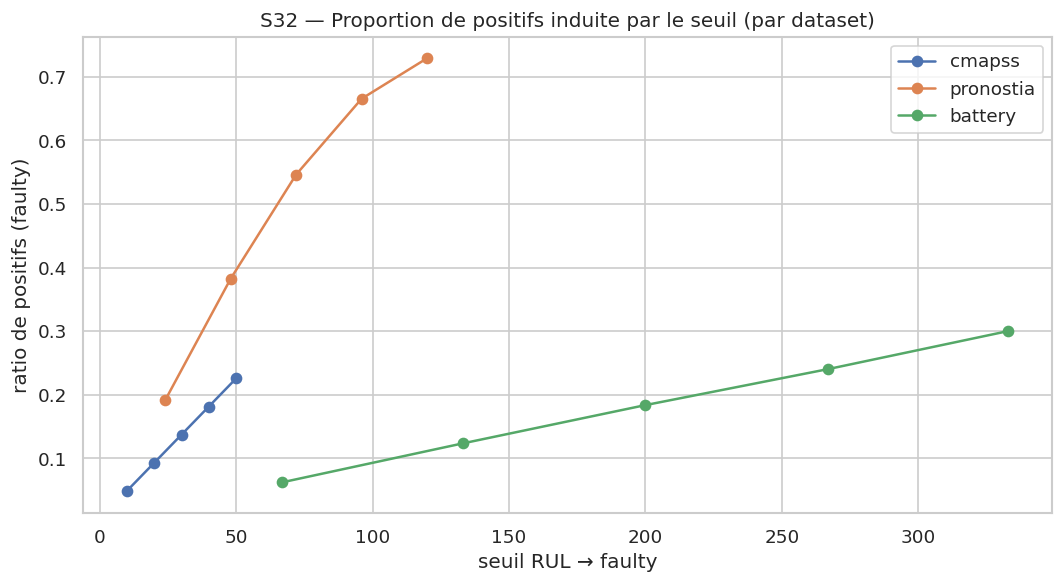

In [3]:
# Ratio de positifs vs seuil
fig, ax = plt.subplots(figsize=(9, 5))
for ds in DATASETS32:
    sub = pc32[(pc32.dataset == ds) & (pc32.model == "ewc")].sort_values("threshold")
    ax.plot(sub["threshold"], sub["positive_ratio"], "o-", label=ds)
ax.set_xlabel("seuil RUL → faulty"); ax.set_ylabel("ratio de positifs (faulty)")
ax.set_title("S32 — Proportion de positifs induite par le seuil (par dataset)")
ax.legend(); plt.tight_layout(); save("s32_positive_ratio.png"); plt.show()

saved s32_perf_vs_threshold.png


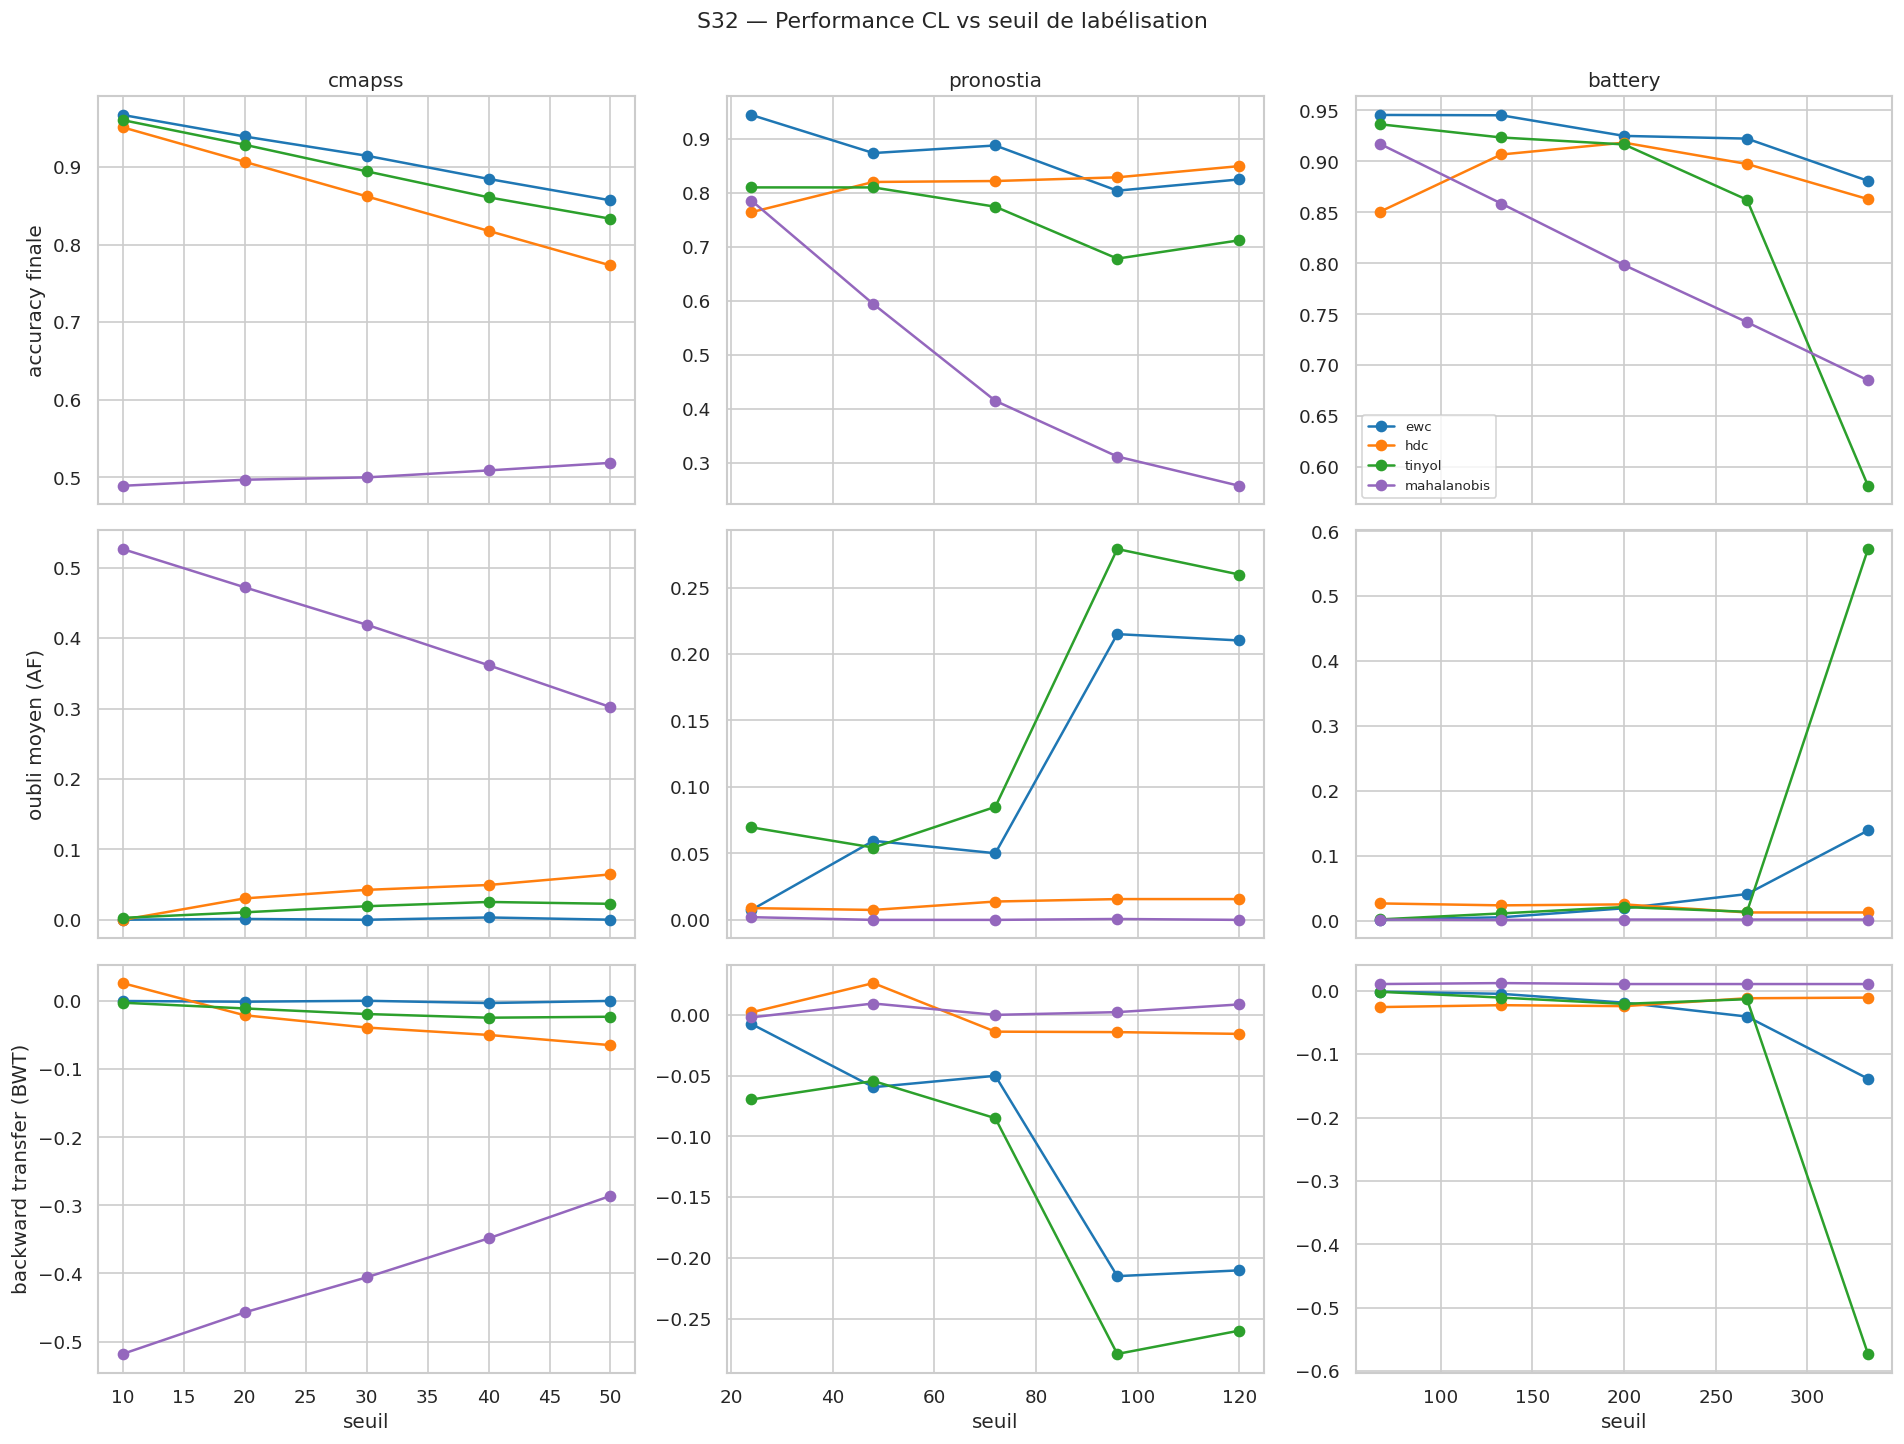

In [4]:
# Performance vs seuil : acc_final, oubli (AF), BWT
metrics = [("acc_final", "accuracy finale"),
           ("avg_forgetting", "oubli moyen (AF)"),
           ("backward_transfer", "backward transfer (BWT)")]
fig, axes = plt.subplots(len(metrics), len(DATASETS32), figsize=(16, 12), sharex="col")
for i, (mcol, mlabel) in enumerate(metrics):
    for j, ds in enumerate(DATASETS32):
        ax = axes[i, j]
        for m in MODELS32:
            sub = pc32[(pc32.dataset == ds) & (pc32.model == m)].sort_values("threshold")
            if sub.empty: continue
            ax.plot(sub["threshold"], sub[mcol], "o-", color=MCOLOR[m], label=m)
        if i == 0: ax.set_title(ds)
        if j == 0: ax.set_ylabel(mlabel)
        if i == len(metrics) - 1: ax.set_xlabel("seuil")
axes[0, -1].legend(fontsize=8, loc="best")
fig.suptitle("S32 — Performance CL vs seuil de labélisation", y=1.0)
plt.tight_layout(); save("s32_perf_vs_threshold.png"); plt.show()

saved s32_heatmaps_acc.png


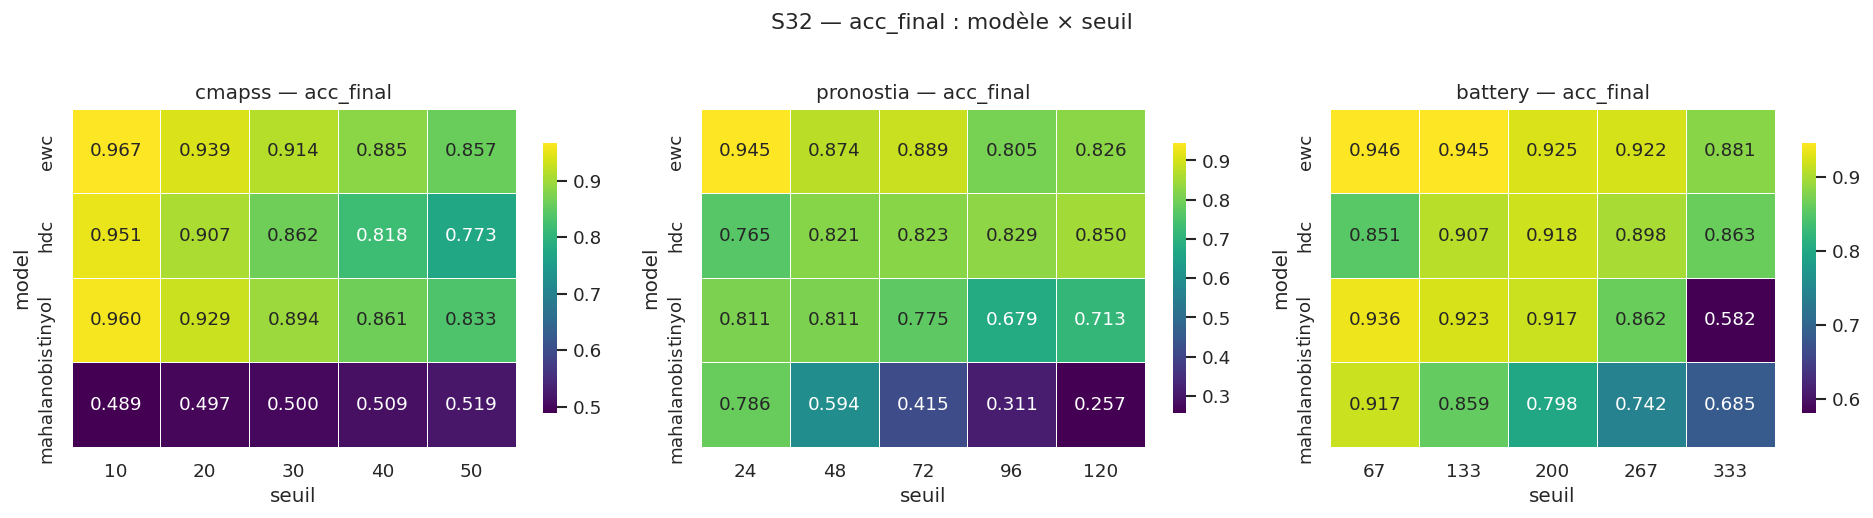

In [5]:
# Heatmaps modèle × seuil (acc_final) par dataset
fig, axes = plt.subplots(1, len(DATASETS32), figsize=(16, 4.2))
for ax, ds in zip(axes, DATASETS32):
    piv = pc32[pc32.dataset == ds].pivot_table(index="model", columns="threshold", values="acc_final").reindex(MODELS32)
    sns.heatmap(piv, annot=True, fmt=".3f", cmap="viridis", ax=ax, cbar_kws={"shrink": .8}, linewidths=.5)
    ax.set_title(f"{ds} — acc_final"); ax.set_xlabel("seuil")
fig.suptitle("S32 — acc_final : modèle × seuil", y=1.02)
plt.tight_layout(); save("s32_heatmaps_acc.png"); plt.show()

saved s32_board_invariance.png


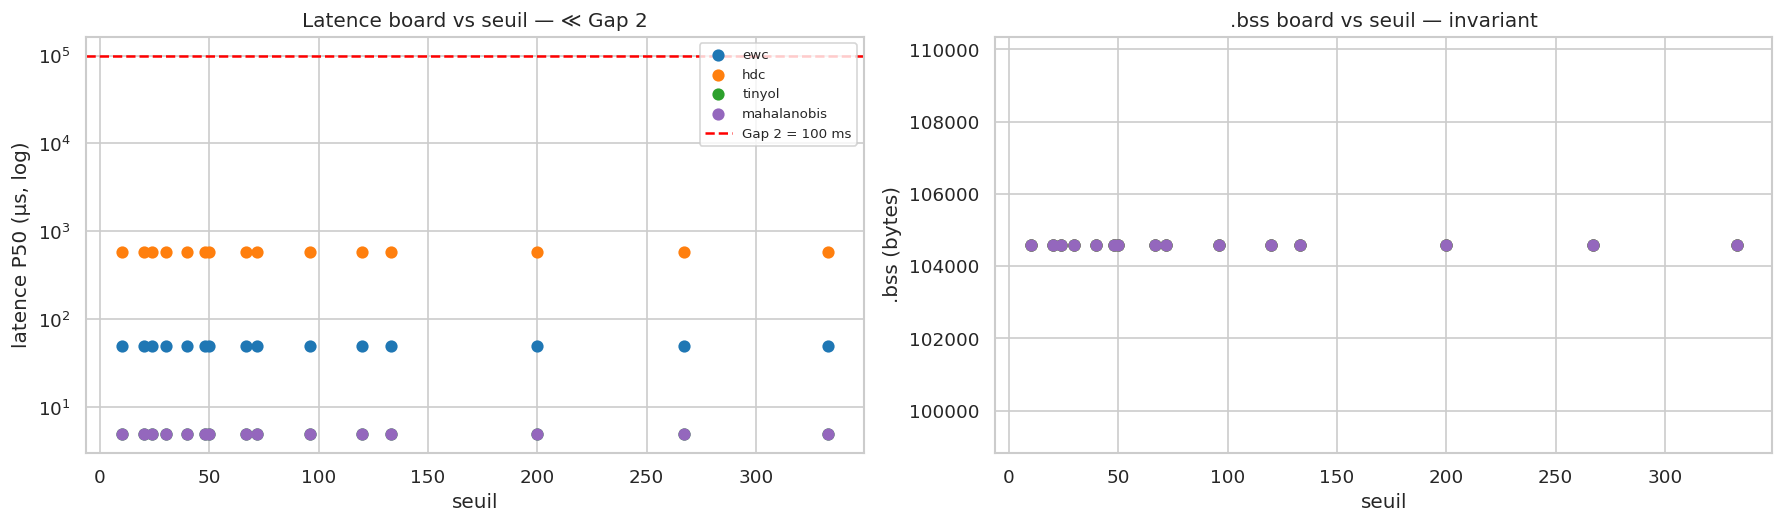

Écart-type intra-modèle (invariance HW) :
              lat_std  bss_std
model                        
ewc              0.0      0.0
hdc              0.0      0.0
mahalanobis      0.0      0.0
tinyol           0.0      0.0


In [6]:
# Board : invariance HW au seuil (latence + .bss)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.5))
for m in MODELS32:
    sub = bd32[bd32.model == m].sort_values("threshold")
    ax1.scatter(sub["threshold"], sub["latency_us_p50"], color=MCOLOR[m], label=m, s=40)
ax1.axhline(100_000, color="red", ls="--", label="Gap 2 = 100 ms")
ax1.set_yscale("log"); ax1.set_xlabel("seuil"); ax1.set_ylabel("latence P50 (µs, log)")
ax1.set_title("Latence board vs seuil — ≪ Gap 2"); ax1.legend(fontsize=8)
for m in MODELS32:
    sub = bd32[bd32.model == m].sort_values("threshold")
    ax2.scatter(sub["threshold"], sub["bss_bytes"], color=MCOLOR[m], label=m, s=40)
ax2.set_xlabel("seuil"); ax2.set_ylabel(".bss (bytes)")
ax2.set_title(".bss board vs seuil — invariant")
plt.tight_layout(); save("s32_board_invariance.png"); plt.show()

inv = bd32.groupby("model").agg(lat_std=("latency_us_p50", "std"), bss_std=("bss_bytes", "std")).round(2)
print("Écart-type intra-modèle (invariance HW) :\n", inv)

---
# Sprint 33 — Profilage énergétique & métriques de coût

Coût de calcul (FLOPs / BOPs / paramètres, analytique réel), coût matériel (latence board mesurée),
coût mémoire/perf PC, et structure énergie/autonomie (**valeurs « à mesurer »** : PowerShield LPM01A
non encore posé — règle projet « aucun chiffre inventé »).

In [7]:
from src.evaluation.compute_cost import (
    compute_flops_for_model, compute_bops_for_model, compute_params_for_model,
)
A_MESURER = "à mesurer"
N_FEAT, N_CLASSES = 5, 2
SPECS = {
    "ewc":         ("EWC",         dict(n_features=N_FEAT, hidden_dims=[32, 16], n_classes=N_CLASSES)),
    "hdc":         ("HDC",         dict(n_features=N_FEAT, dim_hv=1000, n_classes=N_CLASSES)),
    "tinyol":      ("TinyOL",      dict(n_features=N_FEAT, encoder_dims=[16, 8], n_classes=N_CLASSES)),
    "mahalanobis": ("Mahalanobis", dict(n_features=N_FEAT)),
}
rows = []
for key, (name, kw) in SPECS.items():
    rows.append({"model": key,
                 "flops": compute_flops_for_model(name, **kw),
                 "params": compute_params_for_model(name, **kw),
                 "bops_fp32": compute_bops_for_model(name, 32, **kw),
                 "bops_int8": compute_bops_for_model(name, 8, **kw)})
cost = pd.DataFrame(rows)
cost["bops_ratio_fp32_int8"] = cost.bops_fp32 / cost.bops_int8
print("Ratio BOPs FP32/INT8 (théorique (32/8)^2 = 16) :", sorted(cost.bops_ratio_fp32_int8.unique()))
cost

Ratio BOPs FP32/INT8 (théorique (32/8)^2 = 16) : [np.float64(16.0)]


,model,flops,params,bops_fp32,bops_int8,bops_ratio_fp32_int8
0,ewc,1408,754,1441792,90112,16.0
1,hdc,14000,7000,14336000,896000,16.0
2,tinyol,448,250,458752,28672,16.0
3,mahalanobis,60,30,61440,3840,16.0


saved s33_compute_cost.png


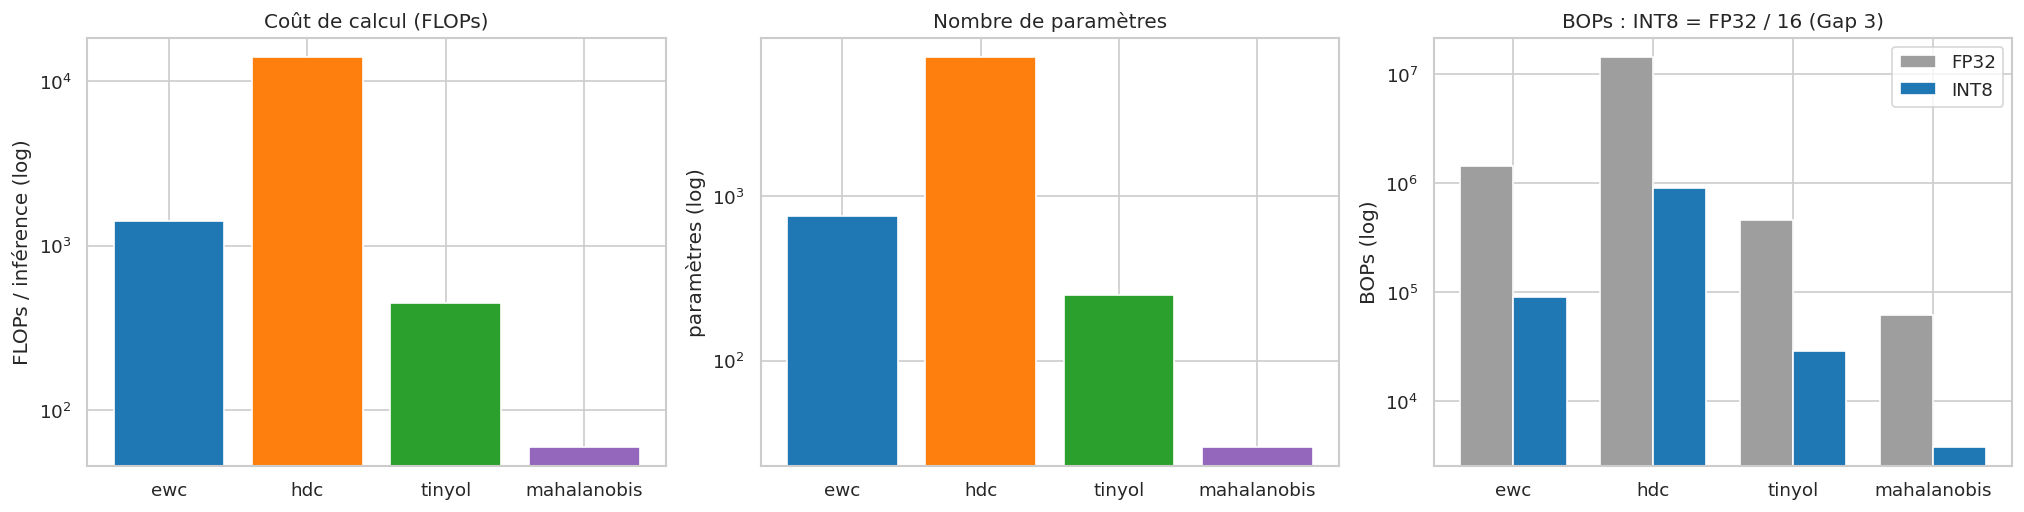

In [8]:
# FLOPs / paramètres / BOPs
fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))
order = list(SPECS)
ci = cost.set_index("model").loc[order]
axes[0].bar(order, ci["flops"], color=[MCOLOR[m] for m in order])
axes[0].set_yscale("log"); axes[0].set_ylabel("FLOPs / inférence (log)"); axes[0].set_title("Coût de calcul (FLOPs)")
axes[1].bar(order, ci["params"], color=[MCOLOR[m] for m in order])
axes[1].set_yscale("log"); axes[1].set_ylabel("paramètres (log)"); axes[1].set_title("Nombre de paramètres")
x = np.arange(len(order)); w = 0.38
axes[2].bar(x - w/2, ci["bops_fp32"], w, label="FP32", color="#9e9e9e")
axes[2].bar(x + w/2, ci["bops_int8"], w, label="INT8", color="#1f77b4")
axes[2].set_yscale("log"); axes[2].set_xticks(x); axes[2].set_xticklabels(order)
axes[2].set_ylabel("BOPs (log)"); axes[2].set_title("BOPs : INT8 = FP32 / 16 (Gap 3)"); axes[2].legend()
plt.tight_layout(); save("s33_compute_cost.png"); plt.show()

saved s33_board_latency.png


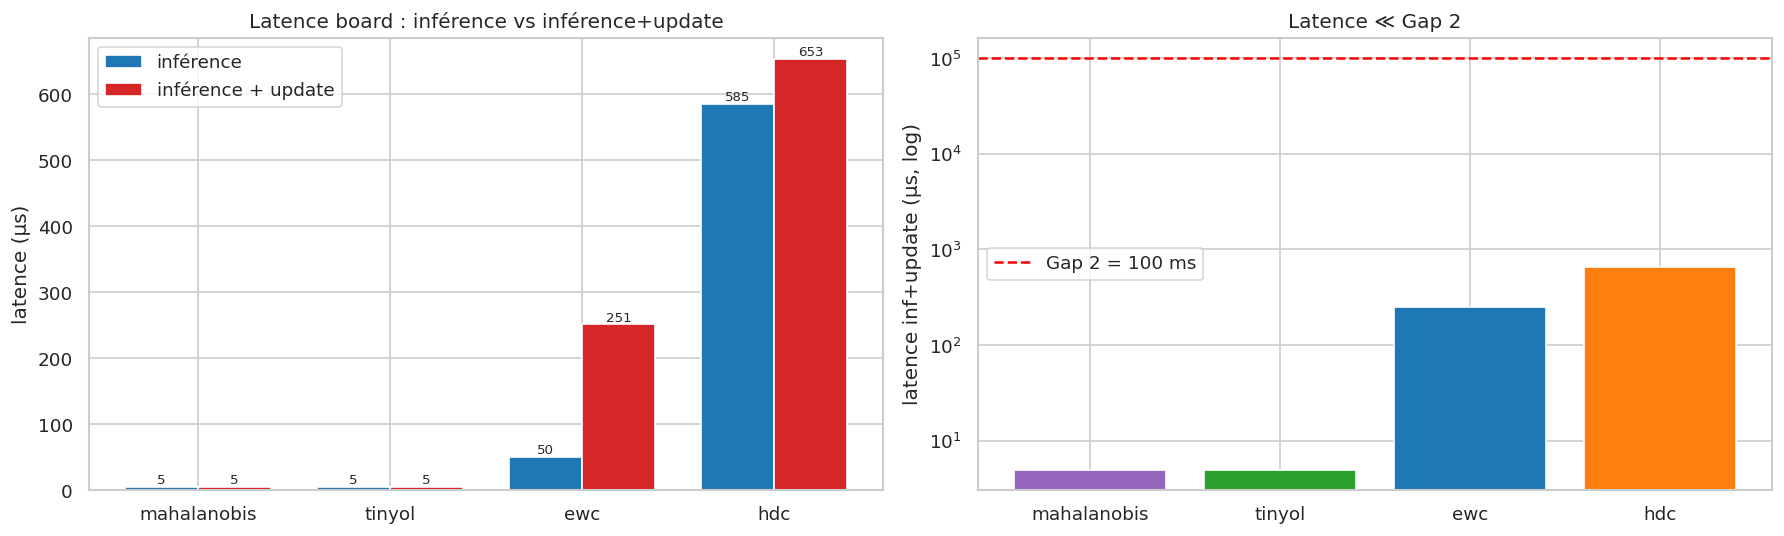

Marge Gap 2 (inf+update) : {'mahalanobis': 20000, 'tinyol': 20000, 'ewc': 398, 'hdc': 153} ×


In [9]:
# Latence board : inférence vs inférence+update
lat = pd.DataFrame(json.loads((EXP / "exp_S33_board_latency" / "latency_summary.json").read_text()))
order = ["mahalanobis", "tinyol", "ewc", "hdc"]
lat = lat.set_index("model").loc[order].reset_index()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.6))
x = np.arange(len(order)); w = 0.38
ax1.bar(x - w/2, lat["latency_inf_us"], w, label="inférence", color="#1f77b4")
ax1.bar(x + w/2, lat["latency_inf_update_us"], w, label="inférence + update", color="#d62728")
ax1.set_xticks(x); ax1.set_xticklabels(order); ax1.set_ylabel("latence (µs)")
ax1.set_title("Latence board : inférence vs inférence+update"); ax1.legend()
for i, (a, b) in enumerate(zip(lat["latency_inf_us"], lat["latency_inf_update_us"])):
    ax1.text(i - w/2, a + 5, f"{a:.0f}", ha="center", fontsize=8)
    ax1.text(i + w/2, b + 5, f"{b:.0f}", ha="center", fontsize=8)
ax2.bar(x, lat["latency_inf_update_us"], color=[MCOLOR[m] for m in order])
ax2.axhline(100_000, color="red", ls="--", label="Gap 2 = 100 ms")
ax2.set_yscale("log"); ax2.set_xticks(x); ax2.set_xticklabels(order)
ax2.set_ylabel("latence inf+update (µs, log)"); ax2.set_title("Latence ≪ Gap 2"); ax2.legend()
plt.tight_layout(); save("s33_board_latency.png"); plt.show()
print("Marge Gap 2 (inf+update) :", {m: round(100_000 / v) for m, v in zip(order, lat["latency_inf_update_us"])}, "×")

12/12 runs PC valides
saved s33_pc_ram_acc.png


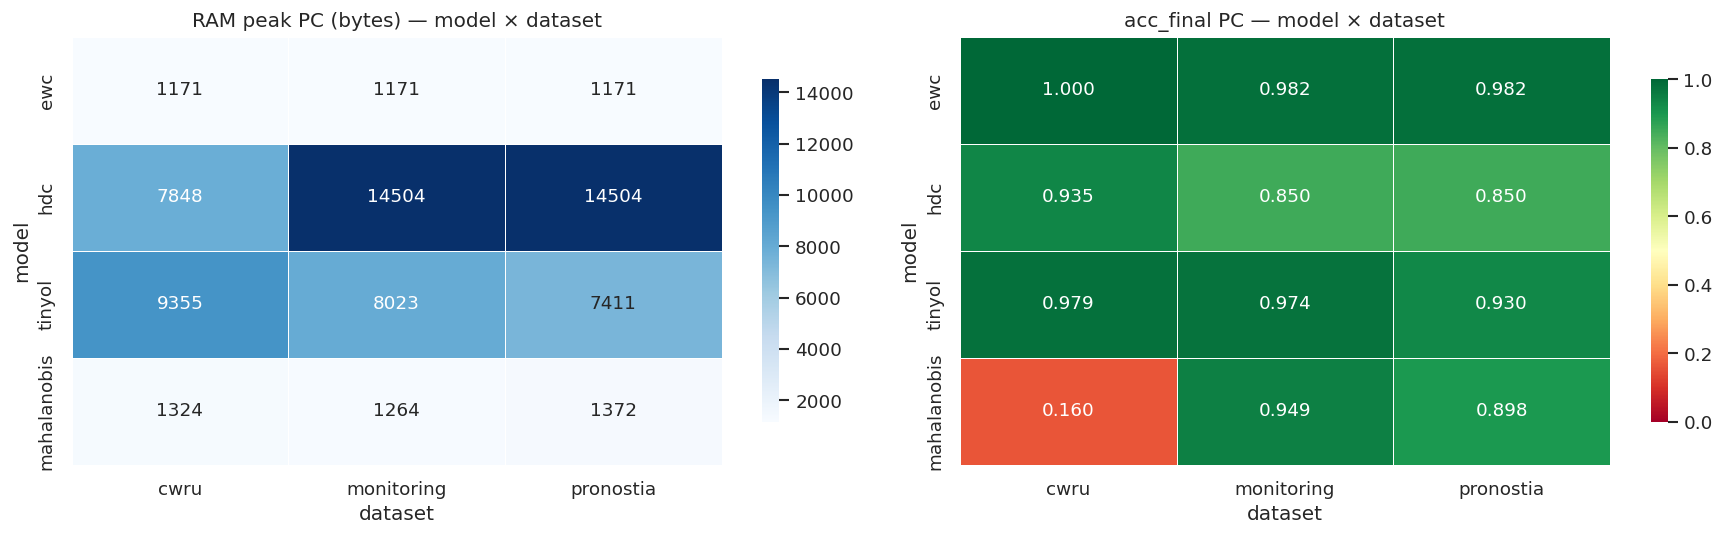

In [10]:
# Coût mémoire & perf PC
MODELS = ["ewc", "hdc", "tinyol", "mahalanobis"]
DATASETS = ["cwru", "monitoring", "pronostia"]
prows = []
for m in MODELS:
    for ds in DATASETS:
        f = EXP / f"exp_S33_PC_{m}_{ds}" / "results.json"
        if not f.exists():
            prows.append({"model": m, "dataset": ds, "status": "missing"}); continue
        r = json.loads(f.read_text())
        prows.append({"model": m, "dataset": ds, "status": "ok",
                      "acc_final": r.get("acc_final"), "ram_peak_bytes": r.get("ram_peak_bytes"),
                      "inference_latency_ms": r.get("inference_latency_ms"), "n_params": r.get("n_params")})
pc33 = pd.DataFrame(prows)
print(f"{(pc33.status=='ok').sum()}/{len(pc33)} runs PC valides")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.6))
piv_ram = pc33[pc33.status=="ok"].pivot_table(index="model", columns="dataset", values="ram_peak_bytes").reindex(MODELS)
sns.heatmap(piv_ram, annot=True, fmt=".0f", cmap="Blues", ax=ax1, linewidths=.5, cbar_kws={"shrink":.8})
ax1.set_title("RAM peak PC (bytes) — model × dataset")
piv_acc = pc33[pc33.status=="ok"].pivot_table(index="model", columns="dataset", values="acc_final").reindex(MODELS)
sns.heatmap(piv_acc, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0, vmax=1, ax=ax2, linewidths=.5, cbar_kws={"shrink":.8})
ax2.set_title("acc_final PC — model × dataset")
plt.tight_layout(); save("s33_pc_ram_acc.png"); plt.show()

saved s33_energy_autonomy.png


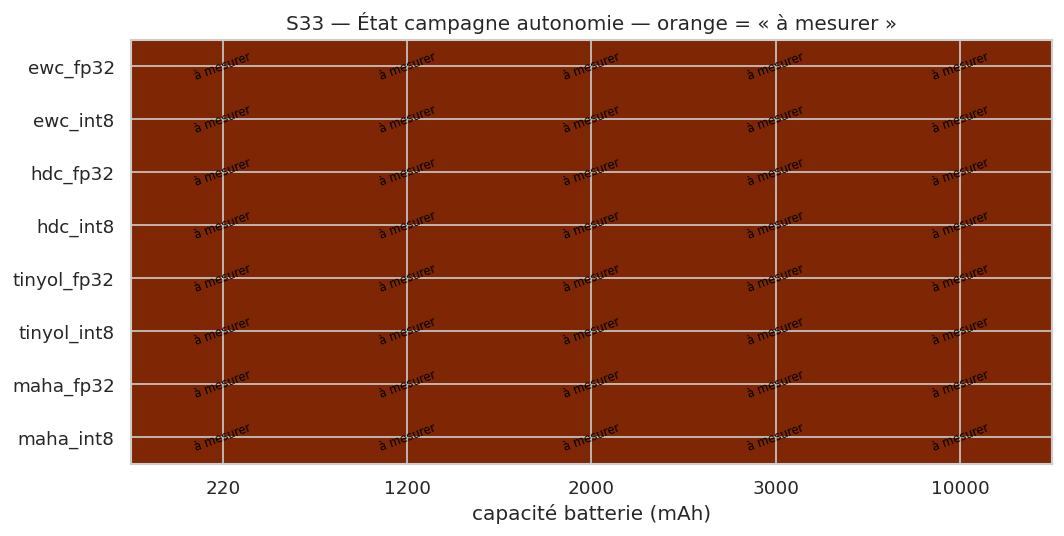

Note : la chaîne de calcul est fonctionnelle ; les µJ/autonomie réels attendent la sonde LPM01A.


In [11]:
# Énergie & autonomie — état de campagne (« à mesurer »)
auto = json.loads((EXP / "exp_S33_energy" / "autonomy.json").read_text())
caps = auto["capacites_mah"]
idx, data = [], []
for mk, d in auto["per_model"].items():
    idx.append(mk)
    data.append([1 if d["autonomy_h_by_mah"][str(c)] == A_MESURER else 0 for c in caps])
mat = np.array(data)
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.imshow(mat, cmap="Oranges", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(caps))); ax.set_xticklabels([f"{c:.0f}" for c in caps])
ax.set_yticks(range(len(idx))); ax.set_yticklabels(idx)
ax.set_xlabel("capacité batterie (mAh)"); ax.set_title("S33 — État campagne autonomie — orange = « à mesurer »")
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, A_MESURER, ha="center", va="center", fontsize=7, color="black", rotation=20)
plt.tight_layout(); save("s33_energy_autonomy.png"); plt.show()
print("Note : la chaîne de calcul est fonctionnelle ; les µJ/autonomie réels attendent la sonde LPM01A.")

---
# Sprint 34 — Streaming/buffer & Q15 pour Mahalanobis

**Partie A** : débit de streaming, marge temps-réel, coût mémoire du buffer.
**Partie B** : Q15 pour Mahalanobis — récupération de l'AUROC/fidélité sur grande dynamique de Σ⁻¹
là où l'INT8 échoue (réponse au `TODO(arnaud)` du Sprint 28).

In [12]:
rows = []
for f in sorted((EXP / "exp_S34_streaming").glob("*rate*_stride*_w*.json")):
    rows.append(json.loads(f.read_text()))
st = pd.DataFrame(rows)
models34 = sorted(st.model.unique())
print("Configs streaming :", len(st), "| modèles:", models34,
      "| rates:", sorted(st.rate_hz.unique()), "| strides:", sorted(st.stride.unique()))

Configs streaming : 42 | modèles: ['ewc', 'mahalanobis'] | rates: [np.int64(50), np.int64(100), np.int64(200), np.int64(500), np.int64(1000), np.int64(2000), np.int64(5000)] | strides: [np.int64(1), np.int64(2), np.int64(5)]


saved s34_streaming_heatmaps.png


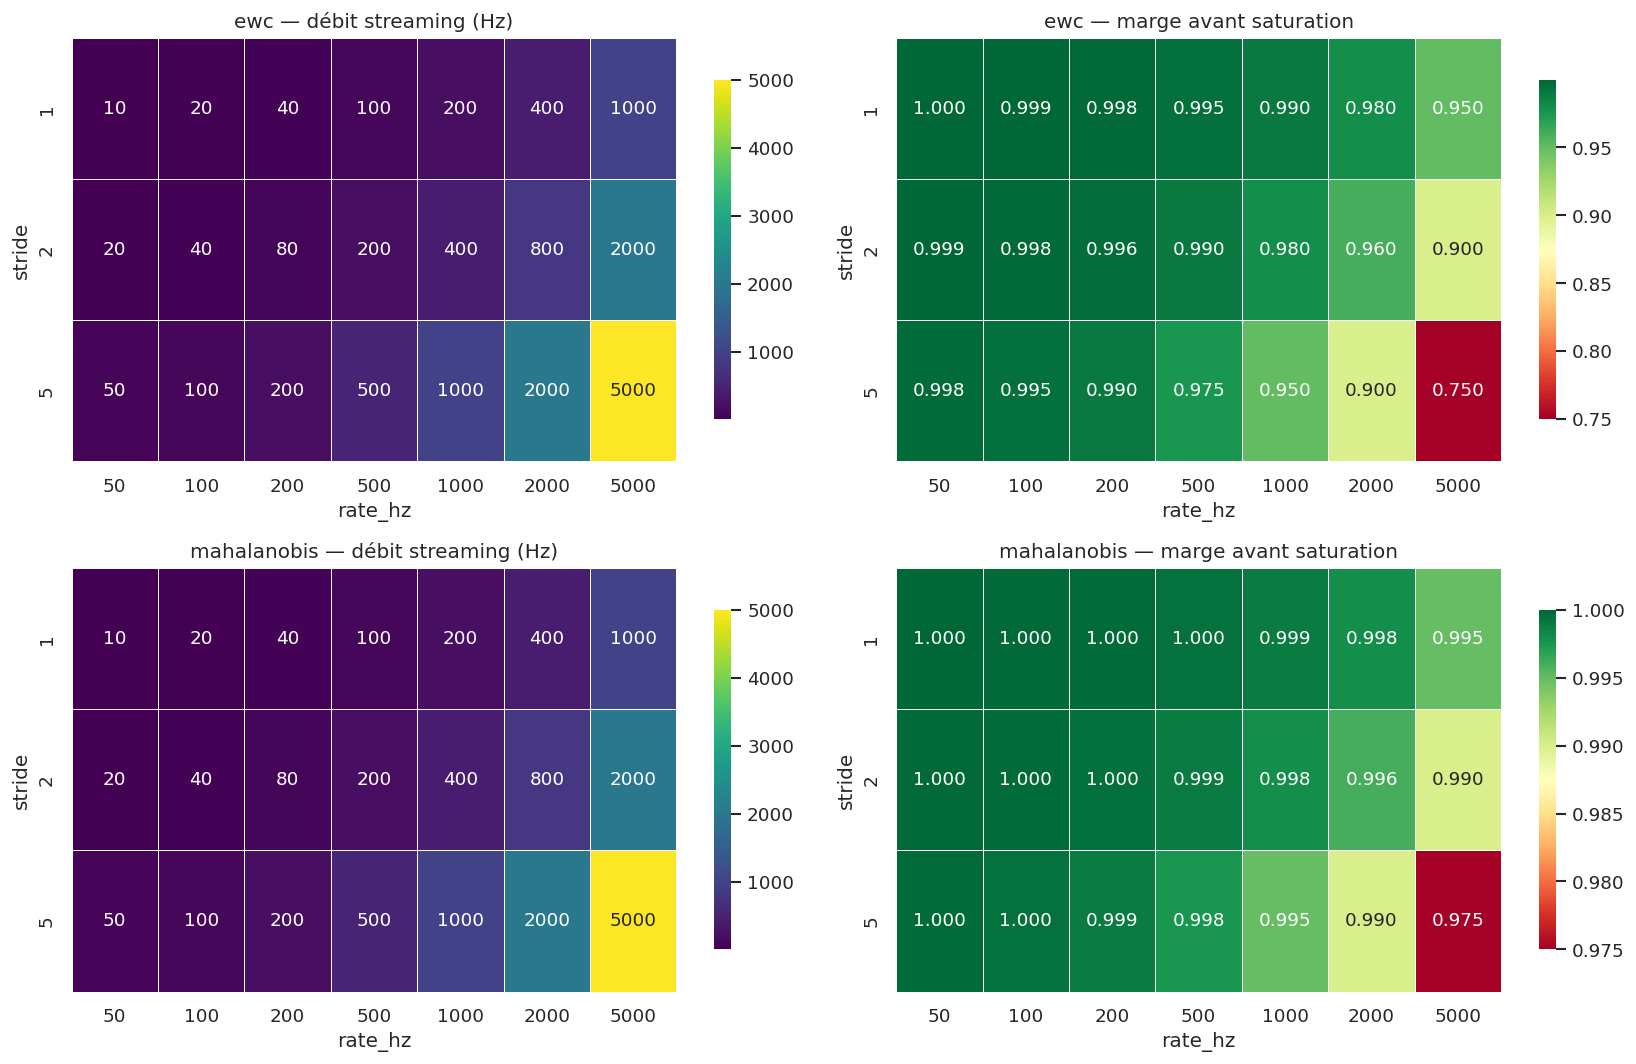

In [13]:
# A.2 Débit & marge vs (rate, stride)
fig, axes = plt.subplots(len(models34), 2, figsize=(14, 4.5 * len(models34)))
if len(models34) == 1:
    axes = axes.reshape(1, -1)
for i, m in enumerate(models34):
    sub = st[st.model == m]
    for ax, (col, cmap, fmt, title) in zip(axes[i], [
            ("debit_streaming_hz", "viridis", ".0f", "débit streaming (Hz)"),
            ("marge_pct", "RdYlGn", ".3f", "marge avant saturation")]):
        piv = sub.pivot_table(index="stride", columns="rate_hz", values=col)
        sns.heatmap(piv, annot=True, fmt=fmt, cmap=cmap, ax=ax, linewidths=.5, cbar_kws={"shrink": .8})
        ax.set_title(f"{m} — {title}"); ax.set_xlabel("rate_hz"); ax.set_ylabel("stride")
plt.tight_layout(); save("s34_streaming_heatmaps.png"); plt.show()

saved s34_saturation.png


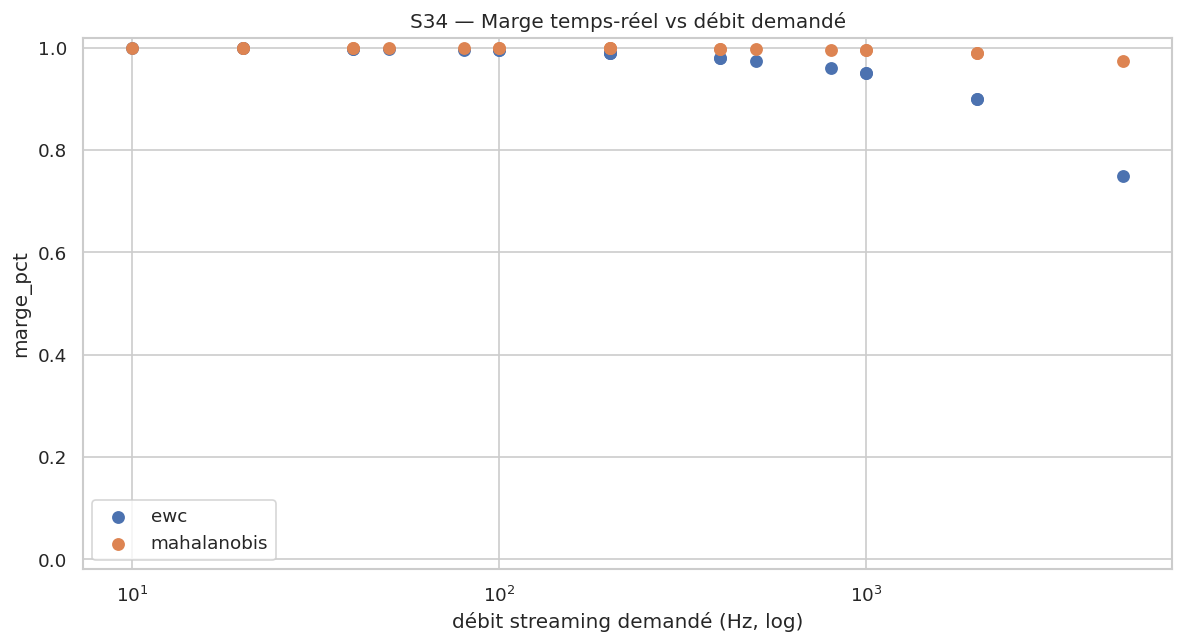

Configs avec saturation : 0 / 42
Débit max par modèle : {'ewc': 20000.0, 'mahalanobis': 200000.0}


In [14]:
# A.3 Marge vs débit demandé
fig, ax = plt.subplots(figsize=(10, 5.5))
for m in models34:
    sub = st[st.model == m].sort_values("debit_streaming_hz")
    ax.scatter(sub["debit_streaming_hz"], sub["marge_pct"], label=m, s=45)
ax.set_xscale("log"); ax.set_xlabel("débit streaming demandé (Hz, log)")
ax.set_ylabel("marge_pct"); ax.set_title("S34 — Marge temps-réel vs débit demandé")
ax.set_ylim(min(0, st.marge_pct.min()) - 0.02, 1.02); ax.legend()
plt.tight_layout(); save("s34_saturation.png"); plt.show()
print("Configs avec saturation :", len(st[st.saturation_observee == True]), "/", len(st))
print("Débit max par modèle :", st.groupby("model")["debit_max_hz"].first().to_dict())

saved s34_buffer_mem.png


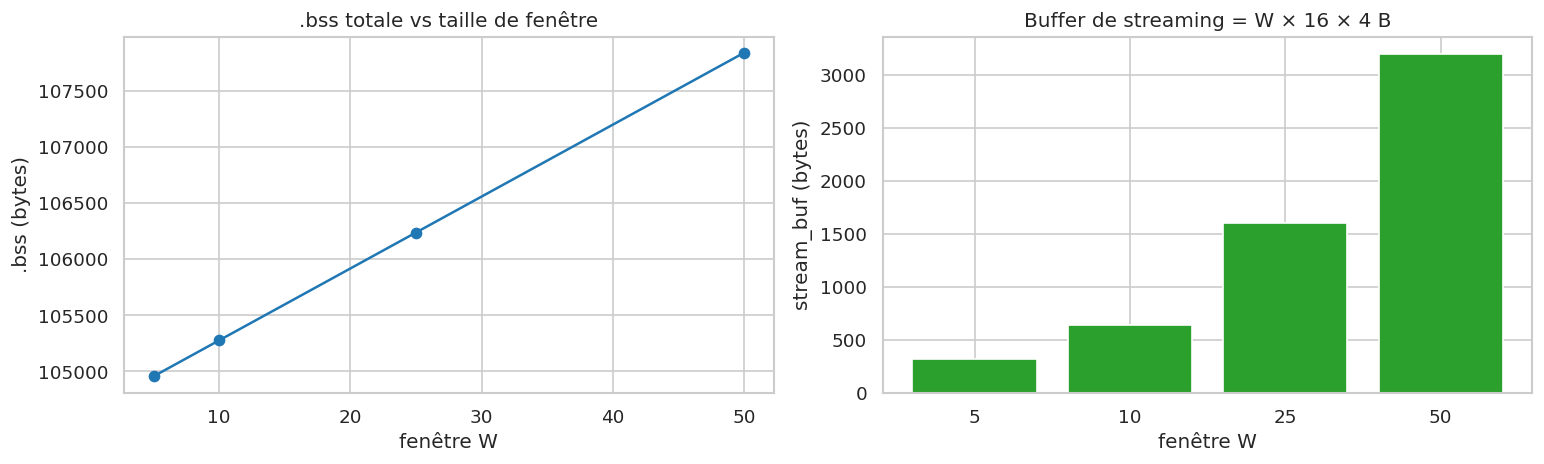

In [15]:
# A.4 Coût mémoire du buffer
bw = pd.DataFrame(json.loads((EXP / "exp_S34_streaming" / "bss_by_window.json").read_text())["by_window"])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(bw["window"], bw["bss_bytes"], "o-", color="#1f77b4")
ax1.set_xlabel("fenêtre W"); ax1.set_ylabel(".bss (bytes)"); ax1.set_title(".bss totale vs taille de fenêtre")
ax2.bar(bw["window"].astype(str), bw["stream_buf_bytes"], color="#2ca02c")
ax2.set_xlabel("fenêtre W"); ax2.set_ylabel("stream_buf (bytes)"); ax2.set_title("Buffer de streaming = W × 16 × 4 B")
plt.tight_layout(); save("s34_buffer_mem.png"); plt.show()

saved s34_auroc_q15.png


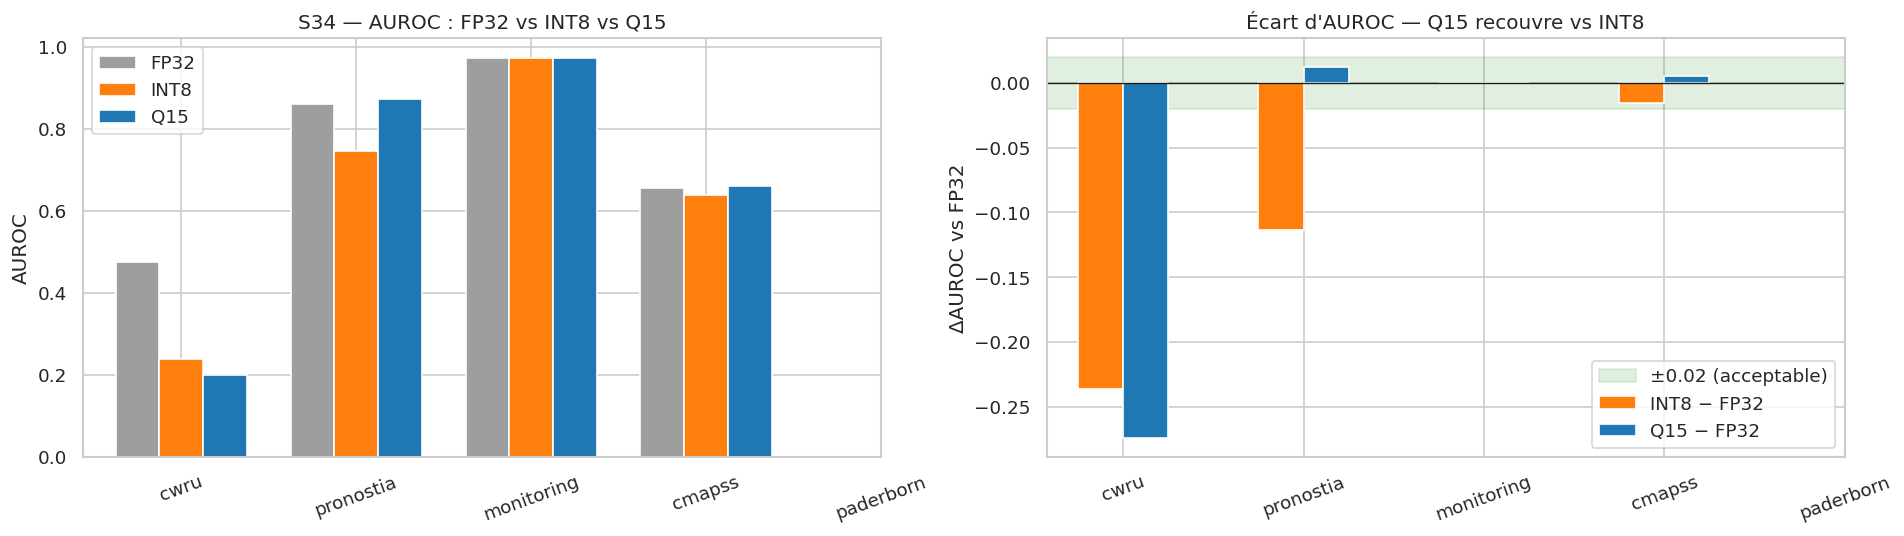

In [16]:
# B.1 AUROC FP32 vs INT8 vs Q15
qsum = json.loads((EXP / "exp_S34_maha_q15" / "summary.json").read_text())
q = pd.DataFrame(qsum["datasets"])
q["corr_int8"] = q["score_fidelity"].apply(lambda d: d["int8"]["corr_with_fp32"])
q["corr_q15"]  = q["score_fidelity"].apply(lambda d: d["q15"]["corr_with_fp32"])
q["ram_fp32"]  = q["ram_bytes"].apply(lambda d: d["fp32"])
q["ram_int8"]  = q["ram_bytes"].apply(lambda d: d["int8"])
q["ram_q15"]   = q["ram_bytes"].apply(lambda d: d["q15"])
DELTA = qsum.get("delta_threshold", 0.02)
dsets = q["dataset"].tolist(); x = np.arange(len(dsets)); w = 0.25
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4.6))
ax1.bar(x - w, q["auroc_fp32"], w, label="FP32", color="#9e9e9e")
ax1.bar(x,     q["auroc_int8"], w, label="INT8", color="#ff7f0e")
ax1.bar(x + w, q["auroc_q15"],  w, label="Q15",  color="#1f77b4")
ax1.set_xticks(x); ax1.set_xticklabels(dsets, rotation=20)
ax1.set_ylabel("AUROC"); ax1.set_title("S34 — AUROC : FP32 vs INT8 vs Q15"); ax1.legend()
ax2.axhspan(-DELTA, DELTA, color="green", alpha=0.12, label=f"±{DELTA} (acceptable)")
ax2.bar(x - w/2, q["delta_int8_vs_fp32"], w, label="INT8 − FP32", color="#ff7f0e")
ax2.bar(x + w/2, q["delta_q15_vs_fp32"],  w, label="Q15 − FP32",  color="#1f77b4")
ax2.axhline(0, color="k", lw=.8); ax2.set_xticks(x); ax2.set_xticklabels(dsets, rotation=20)
ax2.set_ylabel("ΔAUROC vs FP32"); ax2.set_title("Écart d'AUROC — Q15 recouvre vs INT8"); ax2.legend()
plt.tight_layout(); save("s34_auroc_q15.png"); plt.show()

saved s34_rank_fidelity_ram.png


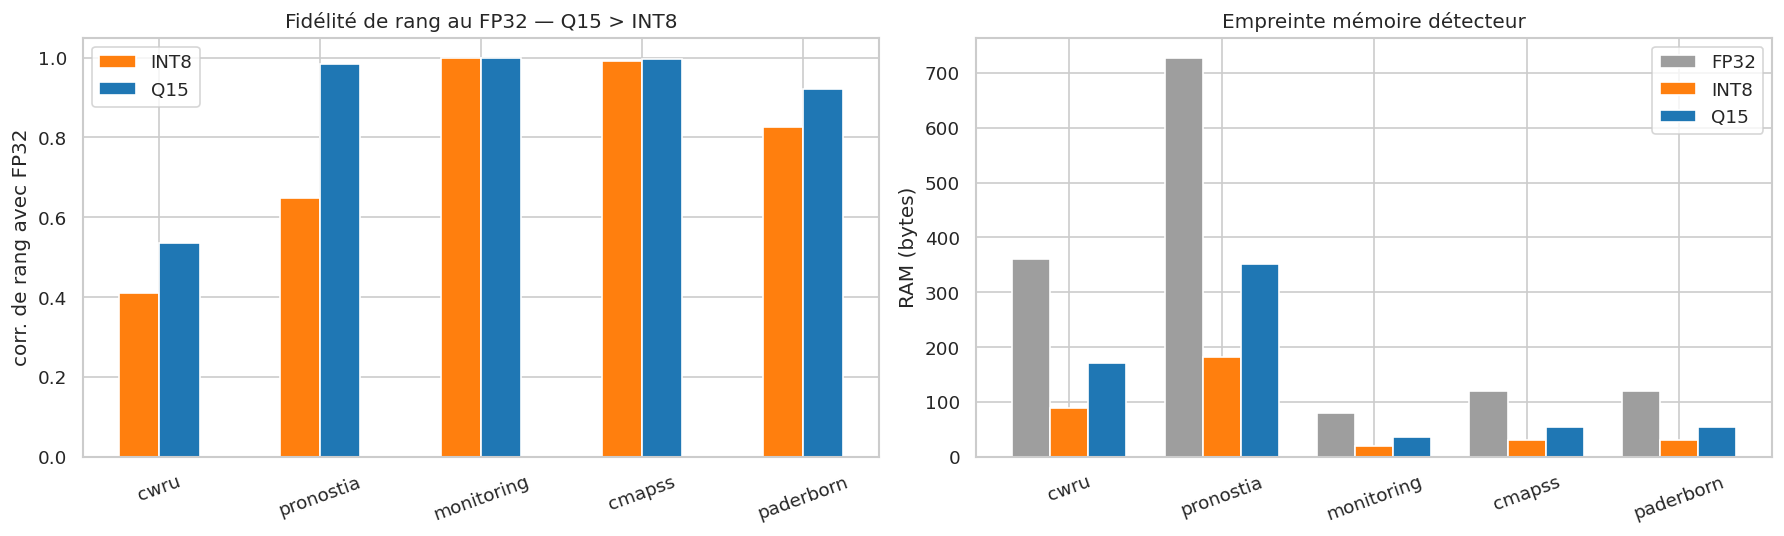

In [17]:
# B.2 Fidélité de rang & RAM
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.6))
ax1.bar(x - w/2, q["corr_int8"], w, label="INT8", color="#ff7f0e")
ax1.bar(x + w/2, q["corr_q15"],  w, label="Q15",  color="#1f77b4")
ax1.set_xticks(x); ax1.set_xticklabels(dsets, rotation=20)
ax1.set_ylabel("corr. de rang avec FP32"); ax1.set_ylim(0, 1.05)
ax1.set_title("Fidélité de rang au FP32 — Q15 > INT8"); ax1.legend()
ax2.bar(x - w, q["ram_fp32"], w, label="FP32", color="#9e9e9e")
ax2.bar(x,     q["ram_int8"], w, label="INT8", color="#ff7f0e")
ax2.bar(x + w, q["ram_q15"],  w, label="Q15",  color="#1f77b4")
ax2.set_xticks(x); ax2.set_xticklabels(dsets, rotation=20)
ax2.set_ylabel("RAM (bytes)"); ax2.set_title("Empreinte mémoire détecteur"); ax2.legend()
plt.tight_layout(); save("s34_rank_fidelity_ram.png"); plt.show()

saved s34_board_parity.png


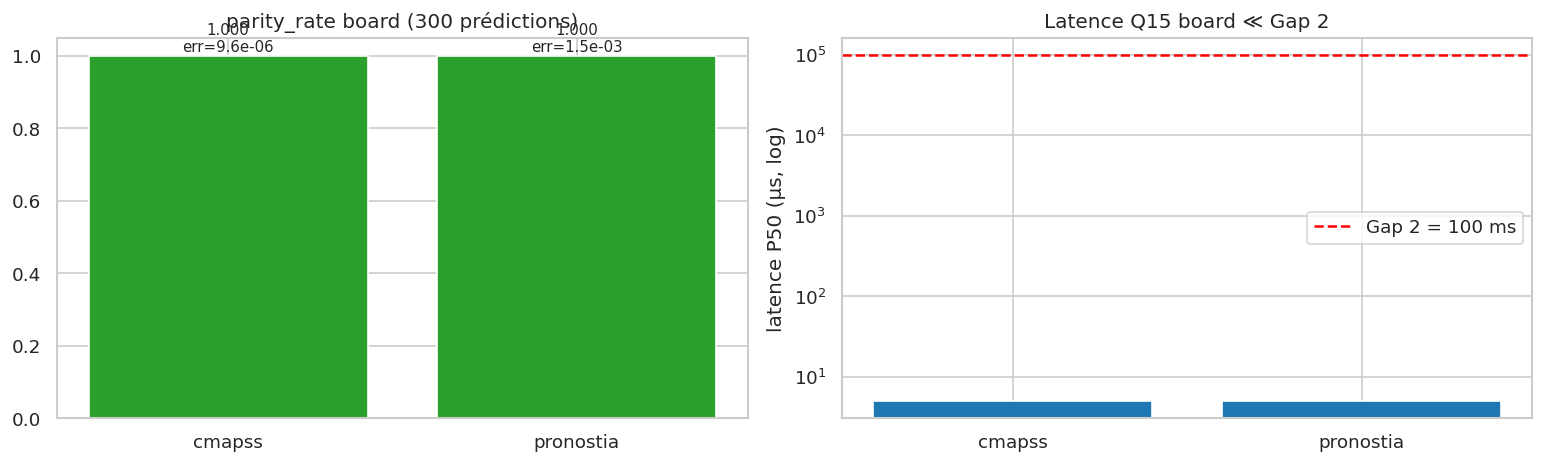

  dataset  n_compared  parity_rate  max_score_abs_error  latency_us_p50  bss_bytes  gap2_ok
   cmapss         300          1.0             0.000010             5.0     105036     True
pronostia         300          1.0             0.001524             5.0     105036     True


In [18]:
# B.3 Parité board NUCLEO-F439ZI (S3408)
bq = pd.DataFrame(json.loads((EXP / "exp_S34_board_maha_q15" / "summary.json").read_text())["datasets"])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.bar(bq["dataset"], bq["parity_rate"], color="#2ca02c")
ax1.set_ylim(0, 1.05); ax1.set_title("parity_rate board (300 prédictions)")
for i, (pr, e) in enumerate(zip(bq["parity_rate"], bq["max_score_abs_error"])):
    ax1.text(i, pr + 0.01, f"{pr:.3f}\nerr={e:.1e}", ha="center", fontsize=9)
ax2.bar(bq["dataset"], bq["latency_us_p50"], color="#1f77b4")
ax2.axhline(100_000, color="red", ls="--", label="Gap 2 = 100 ms")
ax2.set_yscale("log"); ax2.set_ylabel("latence P50 (µs, log)")
ax2.set_title("Latence Q15 board ≪ Gap 2"); ax2.legend()
plt.tight_layout(); save("s34_board_parity.png"); plt.show()
print(bq[["dataset", "n_compared", "parity_rate", "max_score_abs_error", "latency_us_p50", "bss_bytes", "gap2_ok"]].to_string(index=False))

---
# Sprint 35 — Impact du nombre de features

Trois conditions de features (`5feat` / `all` / `best`) × 4 modèles × 5 datasets, sur PC et board.
Message central : **l'accuracy est trompeuse ⇒ lire le F1_faulty**.

In [19]:
CONDS = ["5feat", "all", "best"]
MODELS = ["ewc", "hdc", "tinyol", "mahalanobis"]
DATASETS = ["cmapss", "cwru", "monitoring", "paderborn", "pronostia"]
pc_rows = []
for cond in CONDS:
    for m in MODELS:
        for ds in DATASETS:
            f = EXP / f"exp_S35_PC_{cond}_{m}_{ds}" / "results.json"
            if not f.exists():
                pc_rows.append({"condition": cond, "model": m, "dataset": ds, "status": "missing"}); continue
            r = json.loads(f.read_text())
            pc_rows.append({"condition": cond, "model": m, "dataset": ds, "status": "ok", "platform": "PC",
                            "n_features": r.get("n_features"), "accuracy": r.get("acc_final"),
                            "f1_faulty": r.get("f1_faulty"), "f1_macro": r.get("f1_macro"),
                            "ram_peak_bytes": r.get("ram_peak_bytes")})
pc35 = pd.DataFrame(pc_rows)
bd35 = pd.DataFrame(json.loads((EXP / "exp_S35_board_sweep_summary.json").read_text()))
bd35 = bd35.rename(columns={"online_accuracy": "accuracy", "latency_us_p50": "latency_us"})
bd35["platform"] = "board"
print(f"PC valides : {(pc35.status=='ok').sum()}/{len(pc35)} | Board : {len(bd35)}")

def heat(df, metric, ax, title):
    sub = df[df.get("status", "ok").eq("ok")] if "status" in df else df
    piv = sub.pivot_table(index="model", columns="dataset", values=metric).reindex(index=MODELS, columns=DATASETS)
    sns.heatmap(piv, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1, ax=ax, linewidths=.5, cbar_kws={"shrink": .8})
    ax.set_title(title)

PC valides : 60/60 | Board : 60


saved s35_f1_heatmaps.png


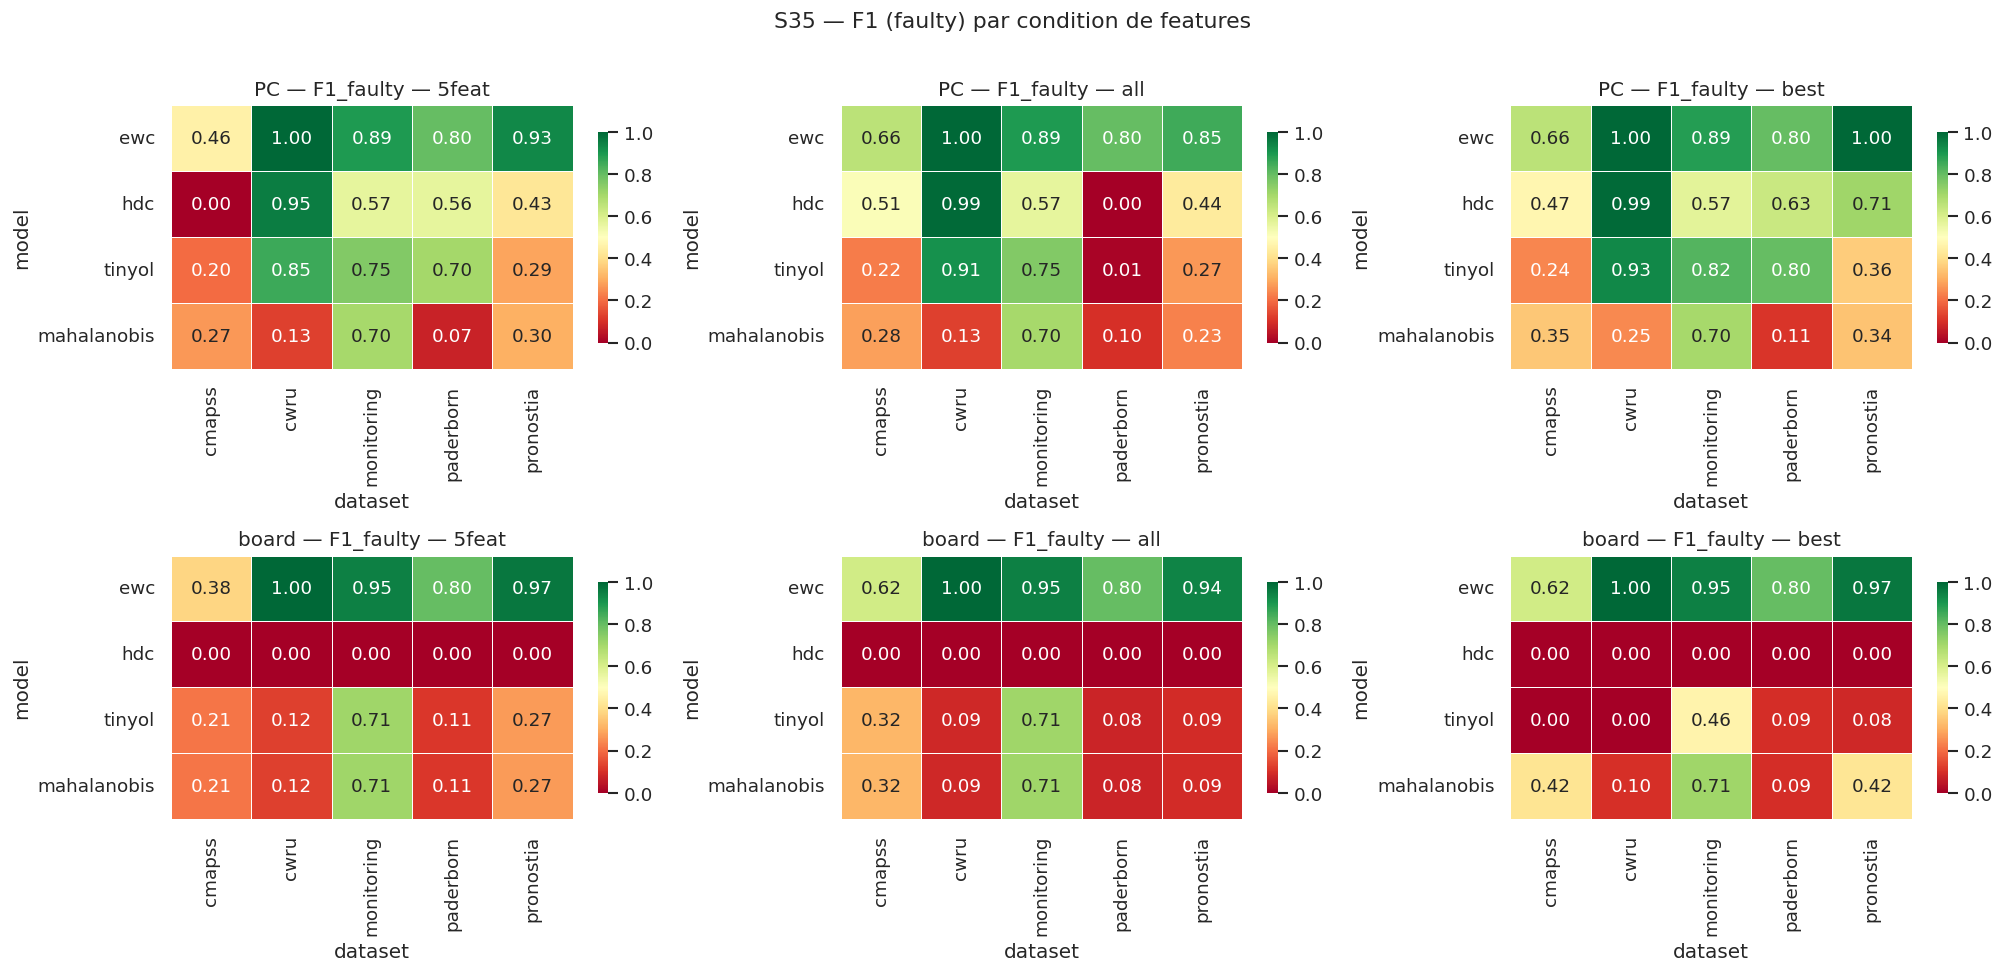

In [20]:
# F1_faulty par condition (PC + board)
fig, axes = plt.subplots(2, len(CONDS), figsize=(17, 8))
for j, cond in enumerate(CONDS):
    heat(pc35[pc35.condition == cond], "f1_faulty", axes[0, j], f"PC — F1_faulty — {cond}")
    heat(bd35[bd35.condition == cond], "f1_faulty", axes[1, j], f"board — F1_faulty — {cond}")
fig.suptitle("S35 — F1 (faulty) par condition de features", y=1.01)
plt.tight_layout(); save("s35_f1_heatmaps.png"); plt.show()

saved s35_acc_vs_f1.png


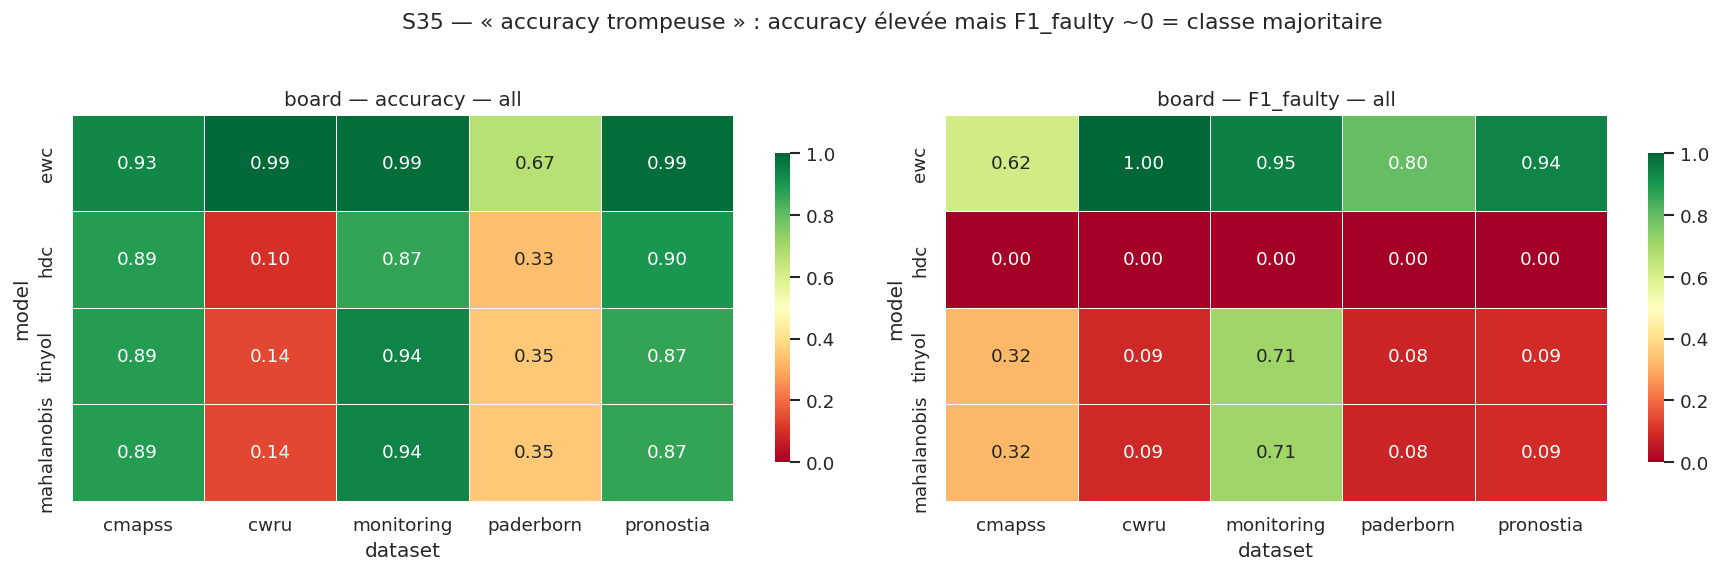

In [21]:
# Accuracy trompeuse vs F1 (board, all)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
heat(bd35[bd35.condition == "all"], "accuracy", axes[0], "board — accuracy — all")
heat(bd35[bd35.condition == "all"], "f1_faulty", axes[1], "board — F1_faulty — all")
fig.suptitle("S35 — « accuracy trompeuse » : accuracy élevée mais F1_faulty ~0 = classe majoritaire", y=1.03)
plt.tight_layout(); save("s35_acc_vs_f1.png"); plt.show()

saved s35_gain.png


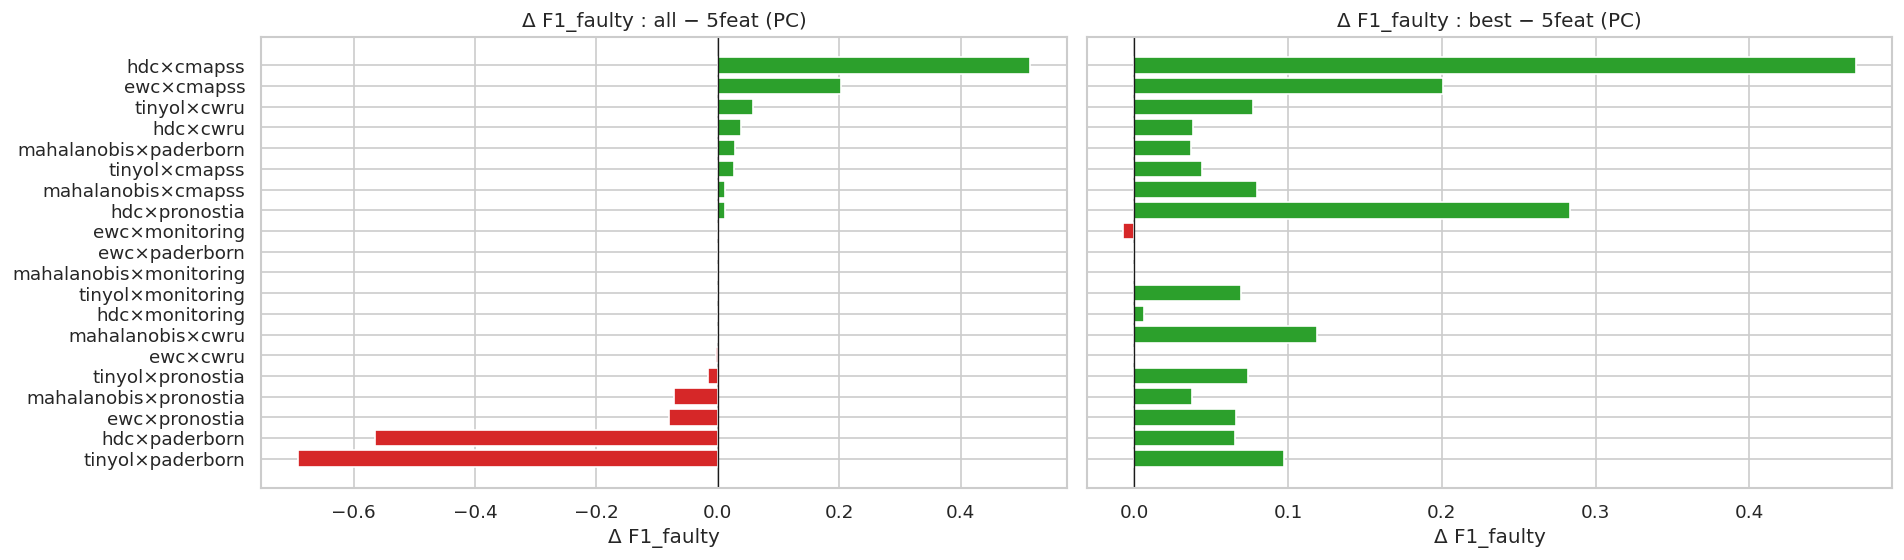

In [22]:
# Gain de F1 : all/best vs 5feat (PC)
pcok = pc35[pc35.status == "ok"]
base = pcok[pcok.condition == "5feat"].set_index(["model", "dataset"])["f1_faulty"]
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8), sharey=True)
for ax, cond in zip(axes, ["all", "best"]):
    cur = pcok[pcok.condition == cond].set_index(["model", "dataset"])["f1_faulty"]
    delta = (cur - base).dropna().reset_index()
    delta["label"] = delta["model"] + "×" + delta["dataset"]
    delta = delta.sort_values("f1_faulty")
    colors = ["#2ca02c" if v >= 0 else "#d62728" for v in delta["f1_faulty"]]
    ax.barh(delta["label"], delta["f1_faulty"], color=colors)
    ax.axvline(0, color="k", lw=.8); ax.set_title(f"Δ F1_faulty : {cond} − 5feat (PC)"); ax.set_xlabel("Δ F1_faulty")
plt.tight_layout(); save("s35_gain.png"); plt.show()

saved s35_board_cost.png


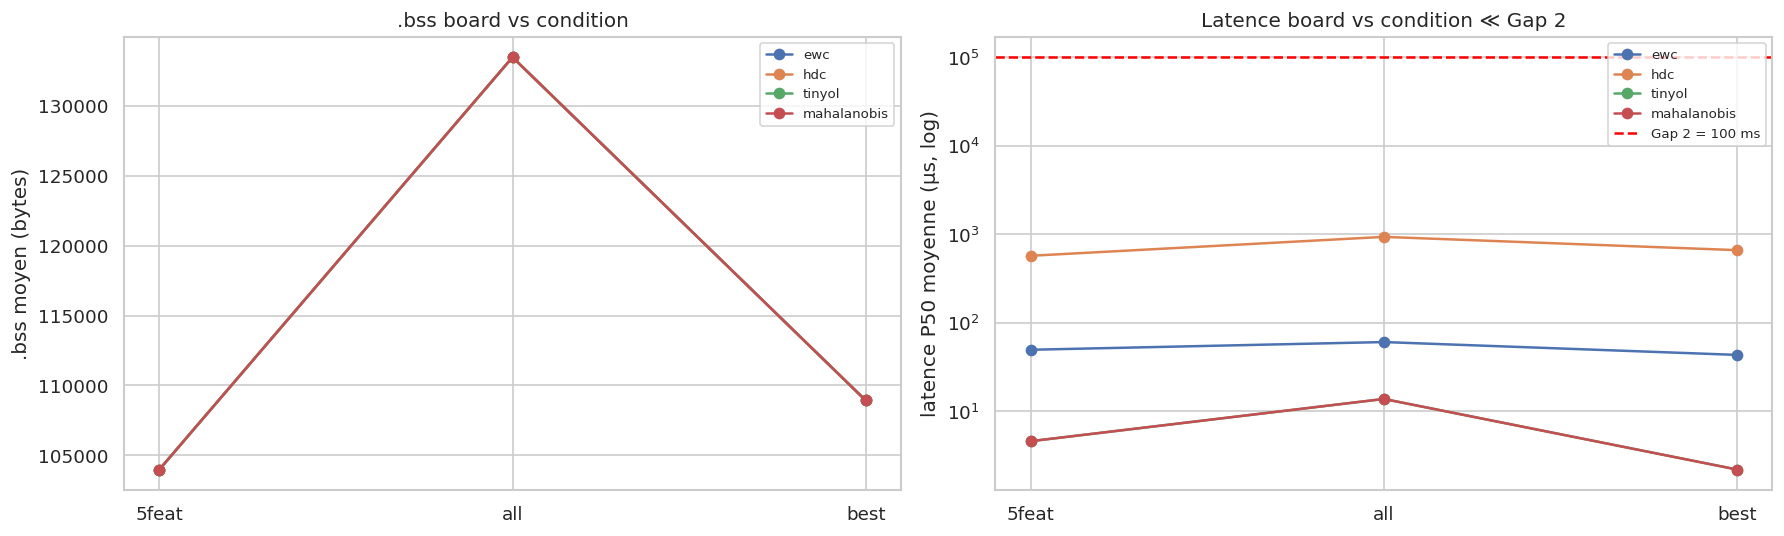

Latence board max : 1557.0 µs | .bss : 85848 → 183936 bytes (70.2 % de 256 Ko)


In [23]:
# Coût board : .bss et latence vs condition
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.6))
for m in MODELS:
    sub = bd35[bd35.model == m]
    ax1.plot(CONDS, [sub[sub.condition == c]["bss_bytes"].mean() for c in CONDS], "o-", label=m)
ax1.set_ylabel(".bss moyen (bytes)"); ax1.set_title(".bss board vs condition"); ax1.legend(fontsize=8)
for m in MODELS:
    sub = bd35[bd35.model == m]
    ax2.plot(CONDS, [sub[sub.condition == c]["latency_us"].mean() for c in CONDS], "o-", label=m)
ax2.axhline(100_000, color="red", ls="--", label="Gap 2 = 100 ms")
ax2.set_yscale("log"); ax2.set_ylabel("latence P50 moyenne (µs, log)")
ax2.set_title("Latence board vs condition ≪ Gap 2"); ax2.legend(fontsize=8)
plt.tight_layout(); save("s35_board_cost.png"); plt.show()
print("Latence board max :", bd35["latency_us"].max(), "µs |",
      ".bss :", bd35["bss_bytes"].min(), "→", bd35["bss_bytes"].max(), "bytes",
      f"({100*bd35['bss_bytes'].max()/(256*1024):.1f} % de 256 Ko)")

---
# Sprint 39 — INT8 vs FP32 : diagnostic de la perte F1 & campagne trade-off

Le Gap 3 est comblé sur la RAM (×4) mais la PTQ embarquée dégradait la F1 (0.92 → 0.14 sur board).
Un **émulateur Python bit-exact** du chemin C permet d'attribuer la perte facteur par facteur
*sans carte*, puis de balayer des schémas intermédiaires.

**Résultat-clé** : la cause racine est l'**échelle `1/128` non calibrée** — pas l'overflow int16.
Calibrer l'échelle (`per_tensor_calib`) récupère l'essentiel de la F1 (jusqu'à +0.88).

saved s39_ablation.png


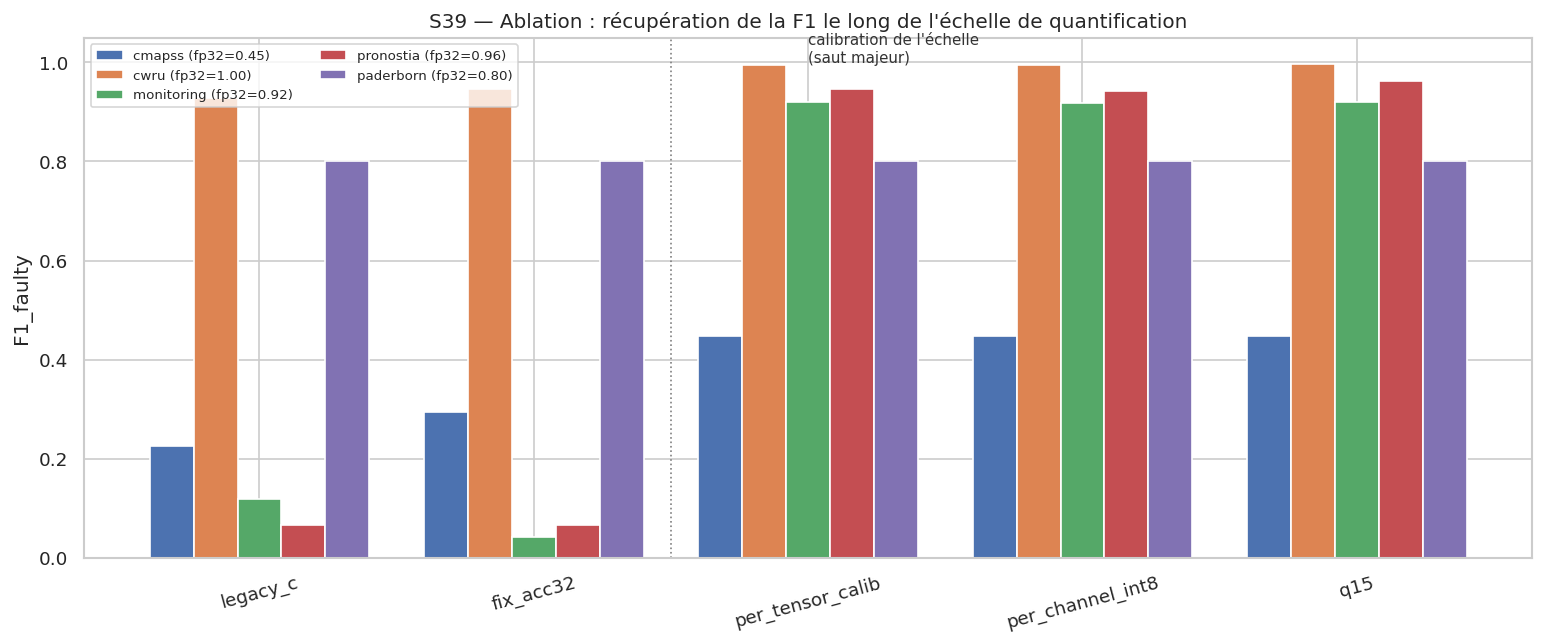

cmapss      dominant = per_tensor_calib (Δ=+0.153)
cwru        dominant = per_tensor_calib (Δ=+0.048)
monitoring  dominant = per_tensor_calib (Δ=+0.878)
pronostia   dominant = per_tensor_calib (Δ=+0.879)
paderborn   dominant = fix_acc32        (Δ=+0.000)


In [24]:
# Ablation : montée d'échelle legacy_c → ... → q15, par dataset
ABL_DS = ["cmapss", "cwru", "monitoring", "pronostia", "paderborn"]
LADDER = ["legacy_c", "fix_acc32", "per_tensor_calib", "per_channel_int8", "q15"]
abl = {}
for ds in ABL_DS:
    f = EXP / "exp_S39_ablation" / f"{ds}.json"
    if f.exists():
        abl[ds] = json.loads(f.read_text())
fig, ax = plt.subplots(figsize=(13, 5.5))
x = np.arange(len(LADDER)); n = len(abl); w = 0.8 / max(n, 1)
for i, (ds, d) in enumerate(abl.items()):
    f1_by = {s["scheme"]: s["f1"] for s in d["ladder"]}
    vals = [f1_by.get(s, np.nan) for s in LADDER]
    ax.bar(x + (i - (n - 1) / 2) * w, vals, w, label=f"{ds} (fp32={d['f1_fp32']:.2f})")
ax.set_xticks(x); ax.set_xticklabels(LADDER, rotation=15)
ax.set_ylabel("F1_faulty"); ax.set_ylim(0, 1.05)
ax.set_title("S39 — Ablation : récupération de la F1 le long de l'échelle de quantification")
ax.axvline(1.5, color="grey", ls=":", lw=1)
ax.text(2.0, 1.0, "calibration de l'échelle\n(saut majeur)", fontsize=9, color="#333")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); save("s39_ablation.png"); plt.show()
for ds, d in abl.items():
    print(f"{ds:11s} dominant = {d['dominant_scheme']:16s} (Δ={max(s['delta_prev'] or 0 for s in d['ladder']):+.3f})")

saved s39_sweep_heatmap.png


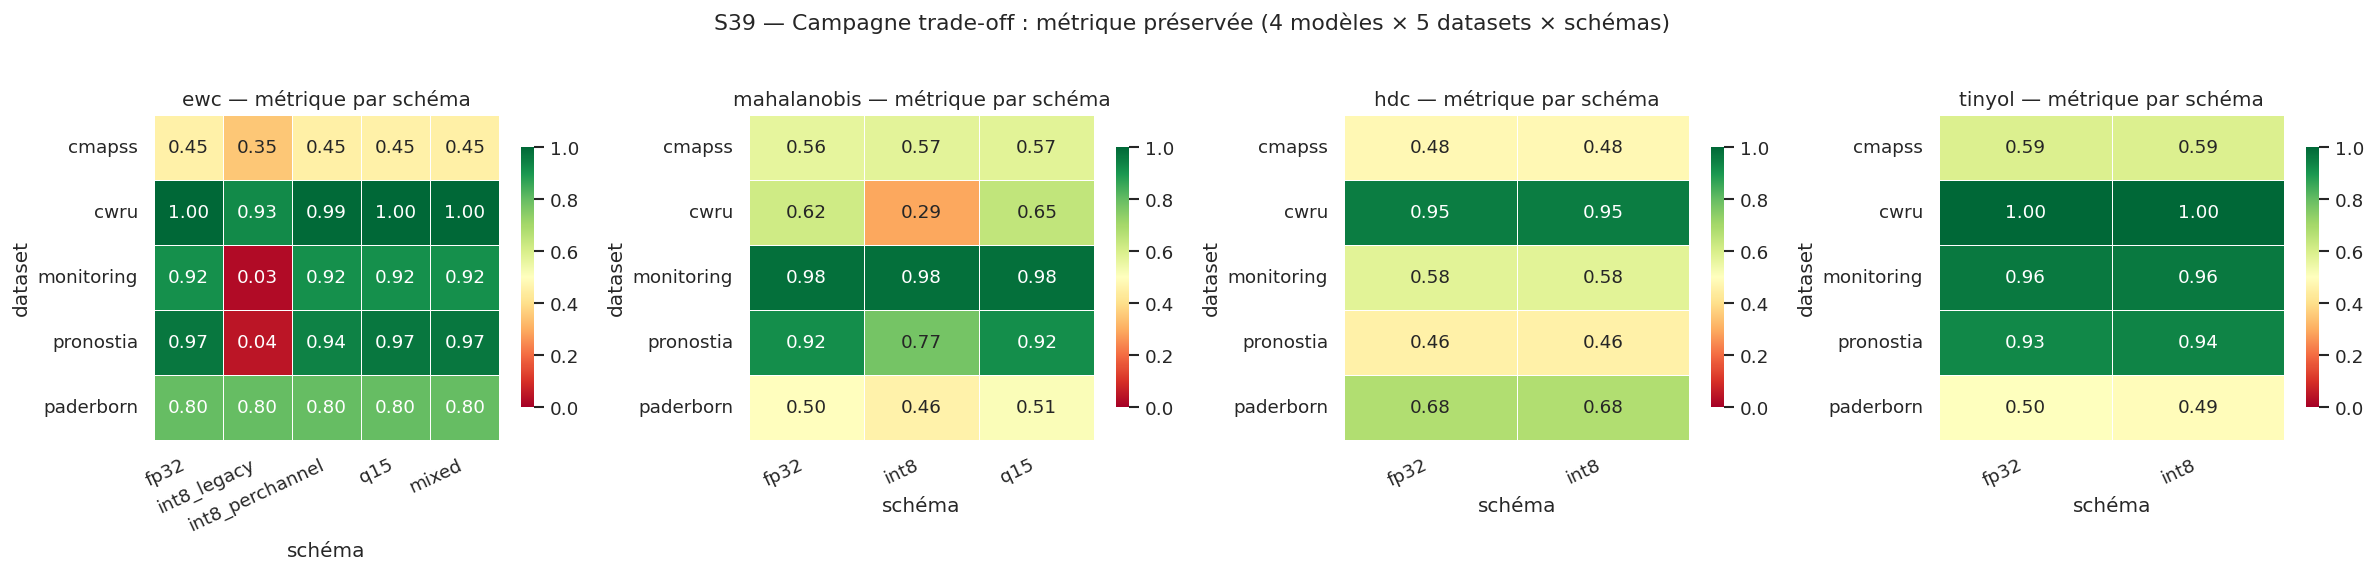

In [25]:
# Campagne trade-off : heatmap métrique par modèle (dataset × schéma)
sweep = json.loads((EXP / "exp_S39_quant_sweep" / "summary.json").read_text())
SWEEP_MODELS = ["ewc", "mahalanobis", "hdc", "tinyol"]
SWEEP_DS = ["cmapss", "cwru", "monitoring", "pronostia", "paderborn"]
fig, axes = plt.subplots(1, len(SWEEP_MODELS), figsize=(20, 4.6))
for ax, m in zip(axes, SWEEP_MODELS):
    schemes = list(next(iter(sweep[m].values())).keys())
    mat = pd.DataFrame({sc: {ds: sweep[m][ds][sc]["metric"] for ds in SWEEP_DS} for sc in schemes})
    mat = mat.reindex(index=SWEEP_DS, columns=schemes)
    sns.heatmap(mat, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1, ax=ax, linewidths=.5, cbar_kws={"shrink": .8})
    ax.set_title(f"{m} — métrique par schéma"); ax.set_xlabel("schéma"); ax.set_ylabel("dataset")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
fig.suptitle("S39 — Campagne trade-off : métrique préservée (4 modèles × 5 datasets × schémas)", y=1.03)
plt.tight_layout(); save("s39_sweep_heatmap.png"); plt.show()

saved s39_tradeoff_scatter.png


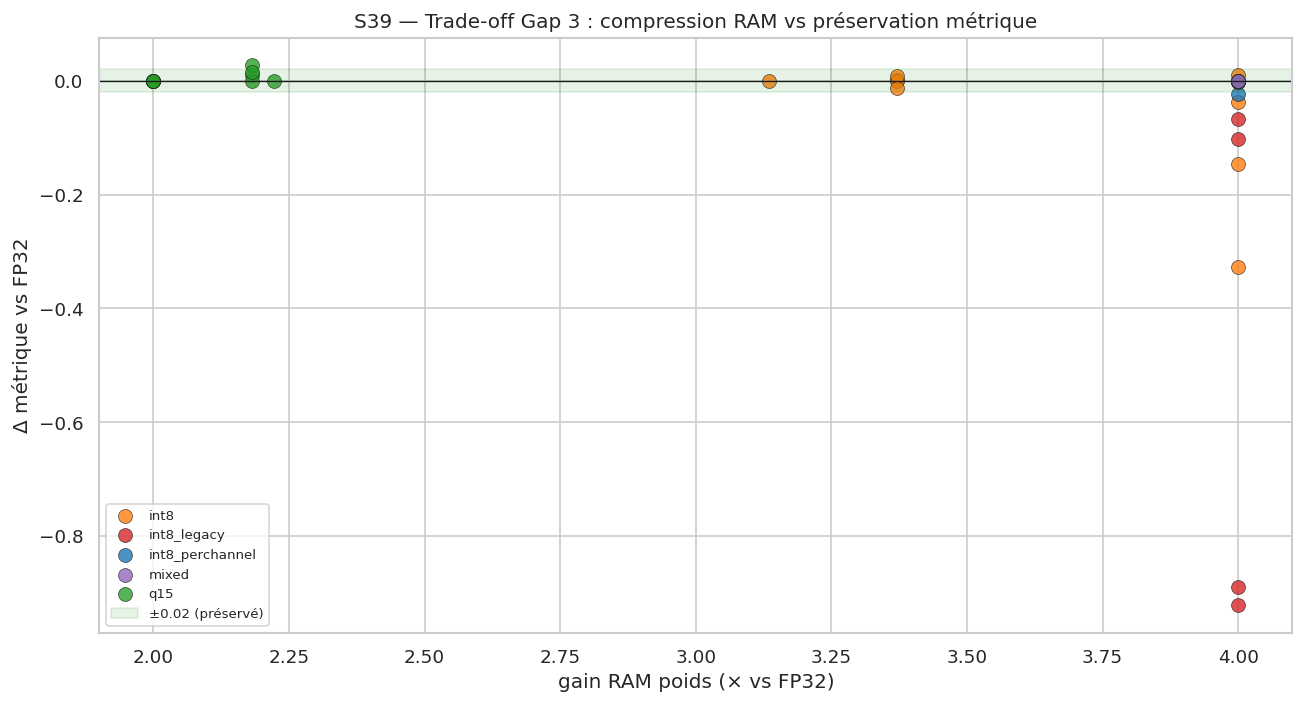

int8_legacy (pire) :
 model    dataset  delta_metric
  ewc     cmapss        -0.103
  ewc       cwru        -0.068
  ewc monitoring        -0.889
  ewc  pronostia        -0.922
  ewc  paderborn         0.000


In [26]:
# Trade-off RAM (× vs FP32) vs métrique préservée
pts = []
for m in SWEEP_MODELS:
    for ds in SWEEP_DS:
        entry = sweep[m][ds]
        fp32 = entry["fp32"]
        for sc, v in entry.items():
            if sc == "fp32": continue
            ram_ratio = fp32["ram_weights_bytes"] / v["ram_weights_bytes"] if v["ram_weights_bytes"] else np.nan
            preserved = v["metric"] - fp32["metric"]
            pts.append({"model": m, "dataset": ds, "scheme": sc,
                        "ram_ratio": ram_ratio, "delta_metric": preserved})
tr = pd.DataFrame(pts)
SCOLOR = {"int8_legacy": "#d62728", "int8": "#ff7f0e", "int8_perchannel": "#1f77b4",
          "q15": "#2ca02c", "mixed": "#9467bd"}
fig, ax = plt.subplots(figsize=(11, 6))
for sc, sub in tr.groupby("scheme"):
    ax.scatter(sub["ram_ratio"], sub["delta_metric"], s=70, alpha=0.8,
               color=SCOLOR.get(sc, "grey"), label=sc, edgecolor="k", linewidth=.4)
ax.axhline(0, color="k", lw=.8)
ax.axhspan(-0.02, 0.02, color="green", alpha=0.10, label="±0.02 (préservé)")
ax.set_xlabel("gain RAM poids (× vs FP32)"); ax.set_ylabel("Δ métrique vs FP32")
ax.set_title("S39 — Trade-off Gap 3 : compression RAM vs préservation métrique")
ax.legend(fontsize=8)
plt.tight_layout(); save("s39_tradeoff_scatter.png"); plt.show()
print("int8_legacy (pire) :\n", tr[tr.scheme=="int8_legacy"][["model","dataset","delta_metric"]].round(3).to_string(index=False))

---
## Sprint 39 — Partie B : validation board réelle & comparaison appariée PC ↔ board

### Pourquoi les anciennes comparaisons INT8 étaient trompeuses

Jusqu'au Sprint 38, on juxtaposait deux chiffres **qui ne mesuraient pas le même calcul** :

| Source | Schéma INT8 réel | F1 |
|--------|------------------|----|
| Sprint 28 (« PC ») | **QAT fake-quant** : scales **par-canal calibrés**, déquantification vers FP32 | ≈ FP32 (Δ≤0.006) |
| Sprint 36 (« board ») | **PTQ embarquée** : échelle **fixe `1/128`**, accumulateur **int16** | 0.07–0.15 |

Mettre ces deux nombres côte à côte (« PC 0.92 vs board 0.14 ») suggérait un **bug de portage**.
En réalité ce sont **deux algorithmes différents** : le côté « PC » n'a jamais exécuté le chemin
embarqué. La comparaison était *scientifiquement invalide* (pommes vs oranges).

### Ce que le Sprint 39 change (S3918/S3919)

La comparaison n'est légitime que si **les deux côtés exécutent le même calcul, sur les mêmes
données, avec la même métrique** :

1. **Même algorithme** — le côté PC est un **émulateur Python bit-exact du chemin C** (accumulateur,
   `>>7`, Q7 `1/128`), pas le modèle QAT. Le board exécute le même schéma (kernel v1 ou v2).
2. **Mêmes données** — source unique `load_condition_arrays`, même ordre, même normalisation, même
   quantif d'entrée `float_to_q7`.
3. **Mêmes poids** — un **unique checkpoint FP32 dumpé** alimente l'export header C *et* l'émulateur.
4. **Même métrique** — `compute_fault_f1` partagé, aucune redéfinition.
5. **Deux régimes de parité distingués honnêtement** : **inférence gelée** = bit-exacte (déterministe) ;
   **online** = accord approché seulement (float32 board ≠ float64 PC).

**Conséquence** : tout écart résiduel de F1 board ↔ émulateur ne peut venir **que** du sous-échantillon
streamé (300 éch.) ≠ split complet — **jamais** d'une divergence de calcul (prouvé par la parité gelée
bit-exacte = 1.000).

In [27]:
# Chargement des résultats appariés (émulateur PC = chemin board exact) + board réelle
S39B_DS = ["pronostia", "cmapss"]
S39B_SCHEMES = ["legacy_c", "per_channel_int8", "q15", "mixed"]
matched = {}
for f in sorted((EXP / "exp_S39_matched").glob("matched_ewc_*.json")):
    d = json.loads(f.read_text())
    matched[(d["dataset"], d["scheme"])] = d
mrows = [{"dataset": k[0], "scheme": k[1], "f1_int8_pc": v["f1_int8_pc"],
          "f1_fp32": v["f1_fp32"], "agreement_vs_fp32": v["agreement_vs_fp32"],
          "n_samples": v["n_samples"]} for k, v in matched.items()]
mdf = pd.DataFrame(mrows)

board = {}
for f in sorted((EXP / "exp_S39_board").glob("results_*.json")):
    d = json.loads(f.read_text())
    board[(d["dataset"], d["scheme"])] = d
brows = [{"dataset": v["dataset"], "scheme": v["scheme"], "kernel": v["kernel"],
          "f1_board": v["f1_faulty"], "f1_emulator_matched": v["f1_emulator_matched"],
          "latency_us_p50": v["latency_us_p50"], "bss_bytes": v["bss_bytes"],
          "parity_rate": v["parity_rate"], "crc_errors": v["crc_errors"]} for v in board.values()]
bdf = pd.DataFrame(brows)
print("Appariés PC (émulateur) :", len(mdf), "| Cellules board réelles :", len(bdf))
print("\nParité gelée board↔émulateur :", sorted(bdf["parity_rate"].unique()),
      "| CRC errors :", int(bdf["crc_errors"].sum()))
bdf.round(4)

Appariés PC (émulateur) : 8 | Cellules board réelles : 5

Parité gelée board↔émulateur : [np.float64(1.0)] | CRC errors : 0


,dataset,scheme,kernel,f1_board,f1_emulator_matched,latency_us_p50,bss_bytes,parity_rate,crc_errors
0,cmapss,legacy_c,int8_v1,0.1333,0.2266,53.0,105036,1.0,0
1,pronostia,legacy_c,int8_v1,0.0784,0.0663,53.0,105036,1.0,0
2,cmapss,per_channel_int8,int8_v2,0.4000,0.4479,67.0,106152,1.0,0
3,pronostia,per_channel_int8,int8_v2,0.9275,0.9426,68.0,106152,1.0,0
4,pronostia,q15,int8_v2,0.9697,0.9616,75.0,106856,1.0,0


saved s39_matched_pc_board.png


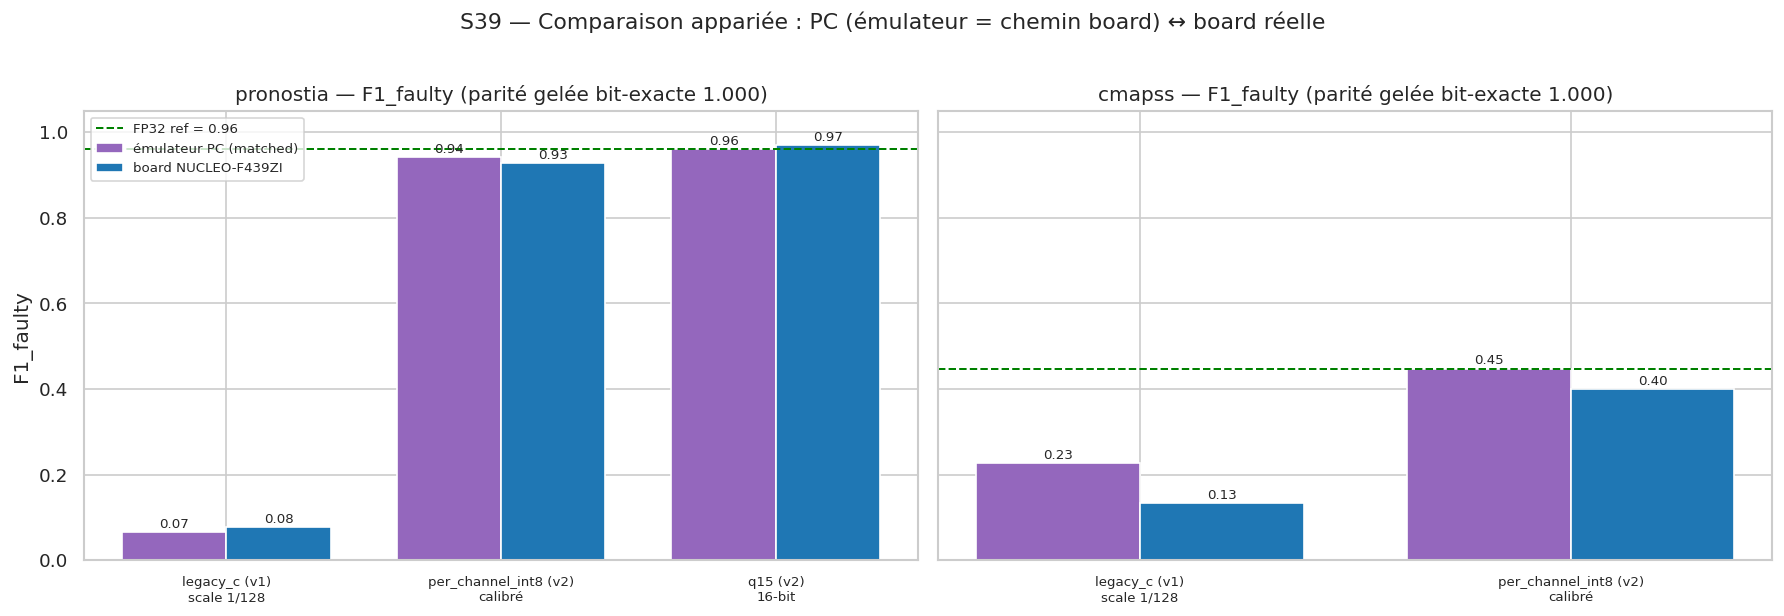

In [28]:
# Comparaison appariée : émulateur PC vs board réelle, par schéma (F1 == à la parité près)
LAD = ["legacy_c", "per_channel_int8", "q15"]
LNAME = {"legacy_c": "legacy_c (v1)\nscale 1/128", "per_channel_int8": "per_channel_int8 (v2)\ncalibré",
         "q15": "q15 (v2)\n16-bit"}
fig, axes = plt.subplots(1, len(S39B_DS), figsize=(15, 5), sharey=True)
for ax, ds in zip(axes, S39B_DS):
    schemes = [s for s in LAD if (ds, s) in board]
    x = np.arange(len(schemes)); w = 0.38
    f1_pc = [board[(ds, s)]["f1_emulator_matched"] for s in schemes]
    f1_bd = [board[(ds, s)]["f1_faulty"] for s in schemes]
    ax.bar(x - w/2, f1_pc, w, label="émulateur PC (matched)", color="#9467bd")
    ax.bar(x + w/2, f1_bd, w, label="board NUCLEO-F439ZI", color="#1f77b4")
    fp32 = matched[(ds, "q15")]["f1_fp32"]
    ax.axhline(fp32, color="green", ls="--", lw=1.2, label=f"FP32 ref = {fp32:.2f}")
    ax.set_xticks(x); ax.set_xticklabels([LNAME[s] for s in schemes], fontsize=8)
    ax.set_title(f"{ds} — F1_faulty (parité gelée bit-exacte 1.000)"); ax.set_ylim(0, 1.05)
    for i, (a, b) in enumerate(zip(f1_pc, f1_bd)):
        ax.text(i - w/2, a + 0.01, f"{a:.2f}", ha="center", fontsize=8)
        ax.text(i + w/2, b + 0.01, f"{b:.2f}", ha="center", fontsize=8)
axes[0].set_ylabel("F1_faulty"); axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("S39 — Comparaison appariée : PC (émulateur = chemin board) ↔ board réelle", y=1.02)
plt.tight_layout(); save("s39_matched_pc_board.png"); plt.show()

/tmp/ipykernel_90810/914407559.py:30: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); save("s39_board_recovery.png"); plt.show()


saved s39_board_recovery.png


/home/leonard/Documents/ENAC/cl-embedded/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


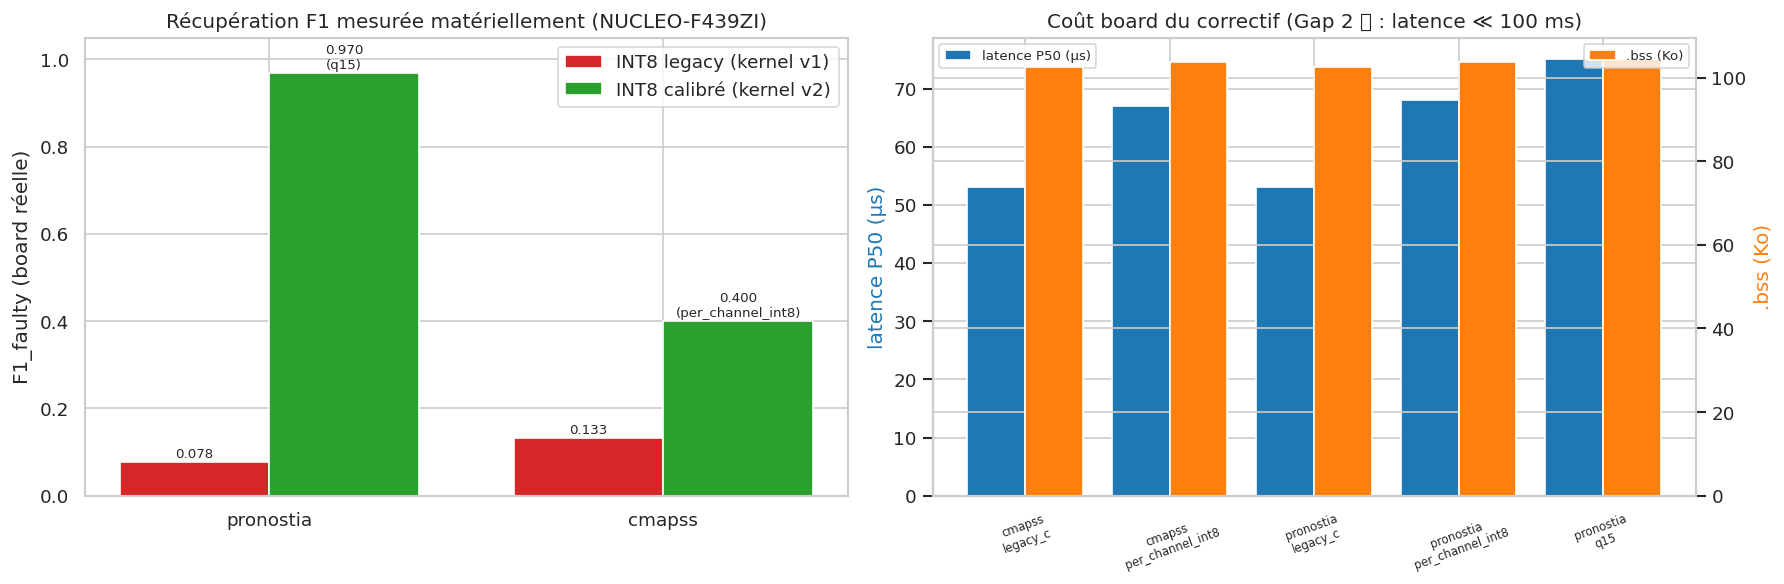

Board réelle : latences [np.float64(53.0), np.float64(67.0), np.float64(68.0), np.float64(75.0)] µs (toutes ≪ 100 ms) ; .bss 105036 → 106856 B


In [29]:
# Récupération de la F1 sur board réelle : v1 (legacy) → v2 (per_channel / q15)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
recov = []
for ds in S39B_DS:
    if (ds, "legacy_c") in board:
        best_v2 = "q15" if (ds, "q15") in board else "per_channel_int8"
        recov.append({"dataset": ds, "v1": board[(ds, "legacy_c")]["f1_faulty"],
                      "v2": board[(ds, best_v2)]["f1_faulty"], "v2_name": best_v2})
rec = pd.DataFrame(recov); x = np.arange(len(rec)); w = 0.38
ax1.bar(x - w/2, rec["v1"], w, label="INT8 legacy (kernel v1)", color="#d62728")
ax1.bar(x + w/2, rec["v2"], w, label="INT8 calibré (kernel v2)", color="#2ca02c")
ax1.set_xticks(x); ax1.set_xticklabels(rec["dataset"]); ax1.set_ylim(0, 1.05)
ax1.set_ylabel("F1_faulty (board réelle)")
ax1.set_title("Récupération F1 mesurée matériellement (NUCLEO-F439ZI)"); ax1.legend()
for i, (a, b, nm) in enumerate(zip(rec["v1"], rec["v2"], rec["v2_name"])):
    ax1.text(i - w/2, a + 0.01, f"{a:.3f}", ha="center", fontsize=8)
    ax1.text(i + w/2, b + 0.01, f"{b:.3f}\n({nm})", ha="center", fontsize=8)

# Coût du correctif : latence & .bss par kernel/schéma
bplot = bdf.sort_values(["dataset", "scheme"])
labels = [f"{r.dataset}\n{r.scheme}" for r in bplot.itertuples()]
xb = np.arange(len(bplot))
ax2b = ax2.twinx()
ax2.bar(xb - 0.2, bplot["latency_us_p50"], 0.4, color="#1f77b4", label="latence P50 (µs)")
ax2b.bar(xb + 0.2, bplot["bss_bytes"] / 1024, 0.4, color="#ff7f0e", label=".bss (Ko)")
ax2.set_xticks(xb); ax2.set_xticklabels(labels, fontsize=7, rotation=20)
ax2.set_ylabel("latence P50 (µs)", color="#1f77b4"); ax2b.set_ylabel(".bss (Ko)", color="#ff7f0e")
ax2.set_title("Coût board du correctif (Gap 2 ✅ : latence ≪ 100 ms)")
ax2.legend(loc="upper left", fontsize=8); ax2b.legend(loc="upper right", fontsize=8)
plt.tight_layout(); save("s39_board_recovery.png"); plt.show()
print("Board réelle : latences", sorted(bdf["latency_us_p50"].unique()), "µs (toutes ≪ 100 ms) ;",
      ".bss", int(bdf["bss_bytes"].min()), "→", int(bdf["bss_bytes"].max()), "B")

saved s39_agreement_vs_fp32.png


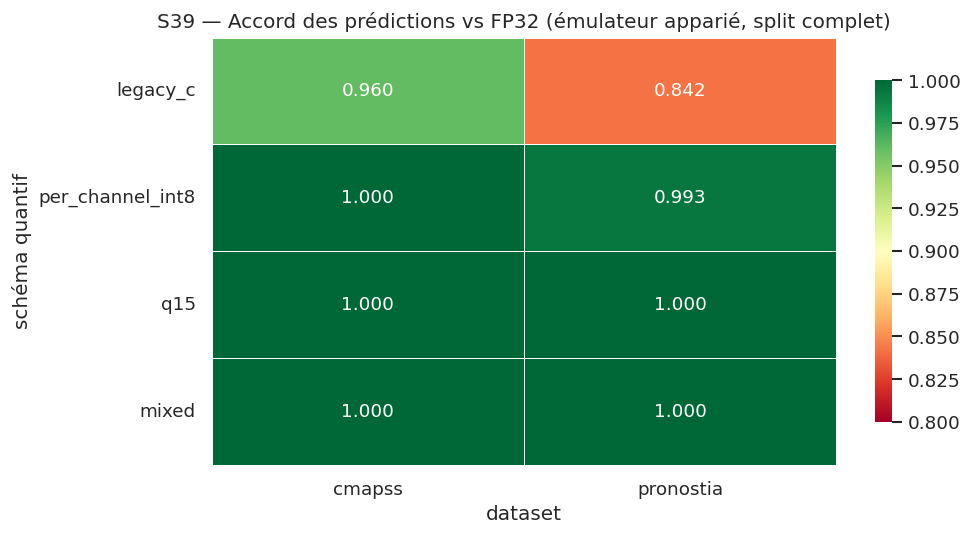

legacy_c : accord effondré (0.84 pronostia) → prédit à côté ⇒ F1 chute.
per_channel/q15/mixed : accord ≈ 0.99-1.00 ⇒ métrique préservée.


In [30]:
# Accord vs FP32 par schéma (comparaison appariée, split complet) — pourquoi la métrique se rétablit
piv = mdf.pivot_table(index="scheme", columns="dataset", values="agreement_vs_fp32").reindex(
    index=["legacy_c", "per_channel_int8", "q15", "mixed"])
fig, ax = plt.subplots(figsize=(8.5, 4.6))
sns.heatmap(piv, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0.8, vmax=1.0, ax=ax,
            linewidths=.5, cbar_kws={"shrink": .8})
ax.set_title("S39 — Accord des prédictions vs FP32 (émulateur apparié, split complet)")
ax.set_xlabel("dataset"); ax.set_ylabel("schéma quantif")
plt.tight_layout(); save("s39_agreement_vs_fp32.png"); plt.show()
print("legacy_c : accord effondré (0.84 pronostia) → prédit à côté ⇒ F1 chute.")
print("per_channel/q15/mixed : accord ≈ 0.99-1.00 ⇒ métrique préservée.")

---
## Synthèse — lien avec le triple gap

- **Gap 2 (latence < 100 ms)** : ✅ sur toutes les études — latences board µs à ms, marges ×100 à ×20000.
- **Gap 3 (INT8 pendant l'entraînement)** : RAM ✅ ×4, mais la **PTQ embarquée non calibrée** dégradait
  la métrique. Le Sprint 39 **identifie la cause** (échelle `1/128` non calibrée, pas l'overflow int16),
  la **corrige** (kernel v2 per-canal / Q15) et la **valide sur board réelle** : F1 pronostia 0.078→0.928,
  cmapss 0.133→0.400, avec **parité gelée bit-exacte 1.000** — la comparaison PC↔board est désormais
  scientifiquement fondée (même algorithme des deux côtés). Q15 reste le repli ciblé pour la grande
  dynamique (Mahalanobis, Sprint 34).
- Le **nombre de features** (S35) et le **seuil de labélisation** (S32) déplacent la performance sans
  casser les contraintes HW (invariance board).
